# Lesson 2: Essentials of Calculus in Python
---



The purpose of this lesson is to help students develop the essential foundational skills for performing calculus in Python.

## Lesson Information


### Lesson Learning Outcomes (LOs)

#### Cyberinfrastructure LOs

By the end of this lesson, students will be able to perform the following cyberinfrastructure (CI) tasks:

1. Encode mathematical functions of one or more variables into SymPy expressions
2. Perform symbolic derivatives of scalar functions of one or more variables in SymPy
3. Perform symbolic indefinite integration of scalar functions of one or more variables in SymPy
4. Perform symbolic definite integration of scalar functions of one or more variables in SymPy
5. Perform numerical quadrature to evaluate definite integrals of one or more variables with SciPy

#### Content LOs


This lesson is primarily meant to introduce the cyberinfrastructure skills for _performing calculus in Python_, rather than serving as a detailed introduction to the calculus concepts themselves. However, some brief conceptual introductions to calculus topics are included throughout as a way to ensure students have a common foundation.

### Lesson Prerequisites

#### Cyberinfrastructure Prereq's

Before beginning this lesson, students are expected to have the following CI skills:
1. Basic Python syntax: variable assignment, calling Python functions, loops, conditional statements
    * {u}`[Introduction to Programming for Molecular Scientists, Lesson 1: Introduction to Python](https://act-cms.molssi.org/portal/lessons/foundational-intro-python/)`
2. Symbolic Algebra in SymPy
    * {u}`[Lesson 1: Introduction to Symbolic Algebra in Python](https://act-cms.molssi.org/portal/lessons/foundational-symbolic-math/#material-1)`

#### Content Prereq's


Students are expected to be able to perform by hand the following operations from single-variable calculus:
- Limits of scalar functions of a single variable
- Ordinary derivatives of scalar functions of a single variable
- Indefinite integrals of scalar functions of a single variable
- Definite integrals of scalar functions of a single variable

:::{note}👀 Author Note: No Assumed Familiarity with Multivariate Calculus
:icon:false
No familiarity with the calculus of scalar functions of multiple variables is assumed. Instead, these concepts are introduced as natural extensions of the calculus of scalar functions of a single variable.
:::

### Resources

#### Cyberinfrastructure Resources

- {u}`[MolSSI Workshop: Python Scripting for Computational Molecular Sciences](https://education.molssi.org/python_scripting_cms/)`
- {u}`[MolSSI CMS Python Workshop: Introduction](https://education.molssi.org/python_scripting_cms/01-introduction/index.html)`
- {u}`[Algebra with SymPy Documentation](https://gutow.github.io/Algebra_with_Sympy/algebra_with_sympy.html)`
- {u}`[Demonstrations of ``algebra_with_sympy`` functionality with the ``Equation`` class](https://gutow.github.io/Algebra_with_Sympy/Demonstration%20of%20equation%20class.html)`

#### Content Resources

Students should refer to the following resources for additional discssion:
* {u}`[OpenStax Calculus Volume 1](https://openstax.org/details/books/calculus-volume-1)` (abbreviated OSCv1 when referenced below)
* {u}`[OpenStax Calculus Volume 2](https://openstax.org/details/books/calculus-volume-2)` (abbreviated OSCv2 when referenced below)
* {u}`[OpenStax Calculus Volume 2](https://openstax.org/details/books/calculus-volume-3)` (abbreviated OSCv3 when referenced below)
* {u}`[OpenStax Chemistry 2e](https://openstax.org/details/books/chemistry-2e)`
* {u}`[OpenStax Atoms-First Chemistry 2e](https://openstax.org/details/books/chemistry-atoms-first-2e)`

### References

Portions of this lesson were inspired by or adapted from: 
* {u}`[OpenStax Calculus Volume 1](https://openstax.org/details/books/calculus-volume-1)` (abbreviated OSCv1 when referenced below)
* {u}`[OpenStax Calculus Volume 2](https://openstax.org/details/books/calculus-volume-2)` (abbreviated OSCv2 when referenced below)
* {u}`[OpenStax Calculus Volume 2](https://openstax.org/details/books/calculus-volume-3)` (abbreviated OSCv3 when referenced below)

## Notebook Setup

### Package Imports

:::{warning} ⚒ Importing necessary packages
:icon: false

Execute the cell below to ensure all necessary Python libraries are loaded.
:::

In [1]:
# EXECUTE: Import some packages that we will use later
## SymPy imports & setting defaults
from algebra_with_sympy import * # Automatically imports sympy
algwsym_config.output.solve_to_list = True # Makes automatic solution outputs a list for usability
from sympy.plotting import plot as symplot
from sympy.plotting import plot3d as symplot3d
from IPython.display import display, Markdown
from sympy.functions.elementary.exponential import log as sylog
from sympy.codegen.cfunctions import log10 as sylog10
## Numerical libraries: Math, NumPy, & SciPy
import math
from math import log as mlog
from math import log10 as mlog10
import numpy as np
import scipy as sp
from scipy.integrate import quad as spquad
from scipy.integrate import dblquad as spdblquad
from scipy.integrate import tplquad as sptplquad
from scipy.integrate import nquad as spnquad
## Sanity check
print(f"This notebook is running Algebra_with_Sympy version {str(algwsym_version)}.")

This notebook is running Algebra_with_Sympy version 1.1.3.


# I. Scalar Functions


Before we begin our exploration of the symbolic calculus of real scalar-valued functions in Python, let's first briefly familiarize ourselves with the behavior of these functions themselves.

## I.A. Scalar Variables in SymPy


By default, SymPy assumes that every variable you declare is a complex number, which behave differently than real scalar variables. While complex numbers are useful throughout physics and chemistry, we are restricting our focus in this lesson to only considering real-valued scalar functions. Because real and complex numbers behave differently, it is imperative that we tell SymPy that are variables are real only when we declare them!

:::{tip} 🐍 Declaring a Real Scalar Variable in SymPy
:icon: false
Variables can be declared to be real by passing the keyword argument `real=True` to the `var()` function,[^fn:sympy-var-predicates] which can later be tested by querying the variable's `.is_real` attribute:
```{code}python
:linenos:
:filename:Python Input
var('x', real=True)
print(x.is_real)
```
```{code}txt
:filename:Cell Output
True
```

[^fn:sympy-var-predicates]: For a full list of assumptions that can be passed to the SymPy `var()` function, refer to {u}`[the Predicates section of the SymPy documentation.](https://docs.sympy.org/latest/guides/assumptions.html#predicates)`.
:::{note}ℹ️ Working Definitions
:icon:false
:class:dropdown
Real Number
: A _real number_ $c$ is any numerical value $-\infty < c < \infty$ that can be measured. The set of all real numbers is denoted $\mathbb{R}$.
    * Examples: $5$, $\pi$, $5.32$

Imaginary Numbers
: _**The** imaginary number_ $i = \sqrt{-1}$. A number $z$ is said to be _purely imaginary_ if it is a multiple of $i$, such that $z=bi$ for real number $b$.

Complex Number
: A _complex number_ $z = a \pm bi$ (for real constants $a,b$) is one which contains both a real and imaginary component. 

Scalar variable
: A _scalar variable_ is one representing only a numerical value, i.e., without an accompanying direction. 
    > Examples: $x = 5$, $y = \pi$, $z = 5.32$

Scalar function
: A _scalar function_ $f(x,\ y,\ z,\ \ldots)$ is a function mapping one or more scalar variables $x,\ y,\ z,\ \ldots$ as input to a single scalar output value $c$
    > Examples: $f(x) = 5x - 3$, $g(x,\ y) = \sin{x}\cos{y}$
::::::


By adding the new `real=True` input to the `var()` function, we have explicitly told SymPy that $x$ _must_ be a real number. In general, we will refer to this as the _mathematical domain_ (or just _domain) of the SymPy variable.

:::{danger}☢️ Danger: Variables with Unspecified Domain May Behave Unphysically
:icon:false
If you declare a SymPy variable without specifying its mathematical domain (i.e., without passing any assumption predicates to `var()`), SymPy will automatically assume it is a general complex number with both a real and imaginary part. Particularly if a variable is meant to represent a physically _observable_ quantity, SymPy's assumption that the variable is actually complex will produce mathematically correct but unphysical behavior!
:::

:::{warning}⚒️ Your Turn
:icon: false
In the cell below, declare real scalar SymPy variables $x$, $y$, and $z$ that we will use throughout the lesson.
:::

In [23]:
# YOUR TURN: Declare real scalar variables x, y, & z


In [7]:
# YOUR TURN: Declare real scalar variables x, y, & z
var('x y z', real=True)

(x, y, z)


Now that we have declared our real scalar variables $x,\ y,\ \&\ z$, how do we declare and use real-valued scalar functions? 

## I.B. Declaring & Evaluating Scalar Functions


Fortunately, defining a scalar function of previously declared variables is exactly like defining an algebraic expression in SymPy! 

### I.B.1. Univariate Scalar Functions


:::{tip} 🐍 Defining & Using a Scalar Function in SymPy
:icon: false
To define a scalar function of a single real variable in SymPy, use a Python assignment statement to assign an algebraic SymPy expression to a Python variable. For example, the linear function
$$f(x) = 5x - 3$$
can be declared by
```{code}python
:linenos:
:filename:Python Input
var('x', real=True)
f = 5*x - 3
```
To call the function $f(x)$ and evaluate it for a particular value of $x$ (e.g., $x = 5$), use the `Equation.subs()` method to substitute the value in for $x$:
```{code}python
:linenos:
:filename:Python Input
f.subs({x: 5})
```
```{code}txt
:filename:Cell Output
22
```
:::

~~~{warning}⚒️ Your Turn: Outputs of Scalar Functions
:icon:false
For each of the variables, scalar functions, and real numbers tabulated below,
1. Insert a new code cell to hold your work, and place a comment on the first line with the question part
2. Declare the variable with appropriate scope
3. Define the function of interest
4. Evaluate the function to a floating point (decimal) output at the given input value for the variable

| Part | Variable         | Variable Domain | Scalar Function            | Input Value              |
|:-----|:-----------------|:----------------|:---------------------------|:-------------------------|
| (a)  | $x$              | Real            | $f(x) = x^3 - 3x + 15$     | $x = 4.5$                |
| (b)  | $\theta$ (theta) | Real            | $g(\theta) = \sin{\theta}$ | $\theta = \frac{\pi}{2}$ |
| (c)  | $t$              | Real            | $h(t) = -4.9t^2$           | $t = 8$                  |

::::{hint} 💡 Hints
:icon:false
:class:dropdown

:::{note}Exponents in Python
:icon:false
:class:dropdown
Remember, to raise a variable to a power in Python you use the `**` operation, so`x**2` would produce $x^2$.
:::
:::{note}Float vs. Symbolic Evaluation
:icon:false
:class:dropdown
SymPy will by default keep irrational numbers (e.g., $\pi$) as exact symbols in the output of `Equation.subs({...})`. To return a float value, make sure to call `Equation.subs({...}).evalf()`.
:::
::::
~~~

In [24]:
# YOUR TURN: Encode & Evaluate Functions


In [4]:
# YOUR TURN: Part (a)
var('x', real=True)
f = x**3 - 3*x + 15
f.subs({x: 4.5})

92.6250000000000

In [5]:
# YOUR TURN: Part (b)
var('theta', real=True)
g = sin(theta)
g.subs({theta: pi/2}).evalf()

1.00000000000000

In [6]:
# YOUR TURN: Part (c)
var('t', real=True)
h = -4.9*t**2
h.subs({t: 8})

-313.600000000000

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that

| Part | Scalar Function            | Input Value              | Output Value |
|:-----|:---------------------------|:-------------------------|:-------------|
| (a)  | $\displaystyle f(x) = x^3 - 3x + 15$     | $\displaystyle x = 4.5$                | $\displaystyle 92.625$ |
| (b)  | $\displaystyle g(\theta) = \sin{\theta}$ | $\displaystyle \theta = \frac{\pi}{2}$ | $\displaystyle 1.0$ |
| (c)  | $\displaystyle h(t) = -4.9t^2$           | $\displaystyle t = 8$                  | $\displaystyle -313.6$ |

:::


### I.B.2 Multivariate Scalar Functions


Many physical systems exist in 3-dimensional space spanned by Cartesian coordinates $(x,y,z)$ (denoted $\mathbb{R}^3$). Still yet others involve relationships between multiple physically observable quantities, e.g., the pressure of an ideal gas depends explicitly on the macroscopic variables $n, V, T$ and parametrically on the ideal gas constant $R$. It is therefore of interest to be able to represent and manipulate such _multivariate_ scalar functions $f(x,y,\ldots)$ in SymPy. 

:::{tip}🐍 Declaring & Evaluating a Multivariate Scalar Function
:icon:false
To define a multivariate scalar function $f(x,y,\ldots)$, simply define the function's expression in terms of more than one previously defined scalar variable. 

For example, the two-dimensional Gaussian function $f(x,y) = e^{-(x^2 + y^2)}$ can be represented and evaluated in SymPy with the syntax
```{code}python
:linenos:
:filename:Syntax Demonstration
# Declare two real Cartesian variables
var('x y', real=True)

# Define 2D Gaussian function
f = exp(-(x**2 + y**2))

# Evaluate the function by passing multiple values to .subs({...})
f.subs({x:0, y:0})
```
:::{note}⏎ Cell Output
:icon:false
$0$
::::::

:::{warning}⚒️ Your Turn
:icon:false
The van der Waals equation of state for the pressure of a real gas is[^fn:vdW-equation]
\begin{equation}
P = \frac{RT}{v - b} - \frac{a}{v^2}
\label{eqn:vdw-real-gas-eqn}
\end{equation}
where $v=\frac{V}{n}$ is the molar volume of the real gas (i.e., the volume of the real gas occupied by $N$ moles of particles), and $a,b$ are the empirically determined _van der Waals constants_ for a given real gas. 

In the cell below, 
1. Declare state variables and define both the ideal gas law and the van der Waals equation
2. Determine the pressure (bar) exerted by exactly 1.00 mol of carbon disulfide gas at 298.15 K in a 1.50 L vessel, according to both the (a) ideal gas law and (b) the van der Waals equation of state.
    * **Note:** For CS{sub}`2`, the van der Waals constants are[^fn:vdW-const-wiki] $a = 11.77\ {\rm L^2\cdot bar\cdot mol^{-2}}$ and $b = 0.07685\ {\rm L\cdot mol^{-1}}$.

[^fn:vdW-equation]: For more information about real gases and the van der Waals equation, refer to {u}`this Wikipedia article](https://en.wikipedia.org/wiki/Van_der_Waals_equation)`.
[^fn:vdW-const-wiki]: Values for the van der Waals constants of CS{sub}`2` taken from {u}`[this Wikipedia entry](https://en.wikipedia.org/wiki/Van_der_Waals_constants_(data_page))`.
:::

In [25]:
# YOUR TURN: Pressure of a real gas


In [164]:
# YOUR TURN: Pressure of a real gas
## Declare variables & define ideal, vdW equations
var('R T v V n b a', real=True)
vdW_P = ((R*T)/(v - b)) - (a / v**2)
ideal_P = (n*R*T)/V

## Substitute v=V/n and explicit values into ideal & vdW to evaluate for pressure
vdW_P_val = float(vdW_P.subs({v:V/n}).subs({R:0.08314, T:298.15, V:1.50, n:1.00, a:11.77, b:0.07685}).evalf())
ideal_P_val = float(ideal_P.subs({R:0.08314, T:298.15, V:1.50, n:1.00}).evalf())

## Printing
print(f"The pressure of CS2 is ")
print(f"\tIdeal Gas Law: P={ideal_P_val:6.3f} bar")
print(f"\tvdW Equation: P={vdW_P_val:6.3f} bar")

The pressure of CS2 is 
	Ideal Gas Law: P=16.525 bar
	vdW Equation: P=12.187 bar


:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have obtained that for CS{sub}`2` under these conditions, the pressure according to each equation of state is
| Equation of State      | Pressure, $P$ (bar)          |
|:----------------------:|:----------------------------:|
| Ideal Gas Law          | $P \approx 16.525{\rm\ bar}$ |
| van der Waals Equation | $P \approx 12.187{\rm\ bar}$ |

:::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving this example should resemble the following:
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN: Pressure of a real gas
## Declare variables & define ideal, vdW equations
var('R T v V n b a', real=True)
vdW_P = ((R*T)/(v - b)) - (a / v**2)
ideal_P = (n*R*T)/V

## Substitute v=V/n and explicit values into ideal & vdW to evaluate for pressure
vdW_P_val = float(vdW_P.subs({v:V/n}).subs({R:0.08314, T:298.15, V:1.50, n:1.00, a:11.77, b:0.07685}).evalf())
ideal_P_val = float(ideal_P.subs({R:0.08314, T:298.15, V:1.50, n:1.00}).evalf())

## Printing
print(f"The pressure of CS2 is ")
print(f"\tIdeal Gas Law: P={ideal_P_val:6.3f} bar")
print(f"\tvdW Equation: P={vdW_P_val:6.3f} bar")
```
```{code}txt
The pressure of CS2 is 
	Ideal Gas Law: P=16.525 bar
	vdW Equation: P=12.187 bar
```
:::

## I.C. Visualizing Scalar Functions with SymPy

It is often useful not just to be able to _evaluate_ a scalar function at a point but also to visualize it graphically. 

:::{tip}🐍 Importing SymPy's Plotting Functionality
:icon:false
:class:dropdown
To leverage SymPy's native plotting infrastructure to do this, we must first import the `sympy.plot()` function, which we have already done on line 9 of the cell executed above in the {u}`[Package Imports](#package-imports)` section, reproduced below (with line 9 highlighted):
```{code}python
:linenos:
:filename:Python Input
:emphasize-lines: 9
# EXECUTE: Import some packages that we will use later
from algebra_with_sympy import * # Automatically imports sympy
algwsym_config.output.solve_to_list = True # Makes automatic solution outputs a list for usability
import math
from math import log as mlog
from math import log10 as mlog10
import numpy as np
import scipy as sp
from sympy.plotting import plot as symplot
from IPython.display import display, Markdown
from sympy.functions.elementary.exponential import log as sylog
from sympy.codegen.cfunctions import log10 as sylog10
print(f"This notebook is running Algebra_with_Sympy version {str(algwsym_version)}.")
```
```{code}txt
This notebook is running Algebra_with_Sympy version 1.1.3.
```
To distinguish the `sympy.plot()` function from any other plotting functionality that we might importa later, we have imported this function with the alias `symplot()`. While it is not expressly necessary to give the function the `symplot` "alias," it is good practice to set descriptive function and variable names so that the user (you!) knows specifically what they're using.
:::

### I.C.1. 2-Dimensional Plots

:::{tip} 🐍 Visualizing a SymPy `Equation`
:icon: false
After the SymPy plot function has been imported as `symplot`, a SymPy `Equation` can be plotted by
```{code}python
:lineos:
symplot(Equation)
```
Further functionality can be found in the {u}`[SymPy Documentation 🔗](https://docs.sympy.org/latest/modules/plotting.html#sympy.plotting.plot.plot)`.
:::

:::{warning}⚒️ Your Turn
:icon: false
In a separate cell for each function, plot $f(x)$, $g(\theta)$, and $h(t)$ that you defined in the exercise above.
:::

In [26]:
# YOUR TURN: Visualizing Functions


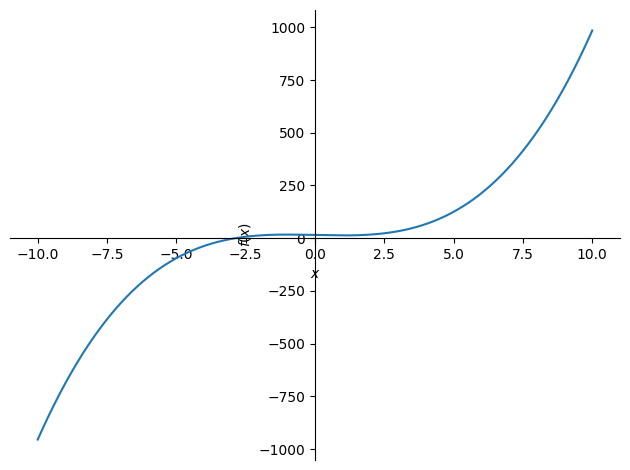

In [16]:
symplot(f)

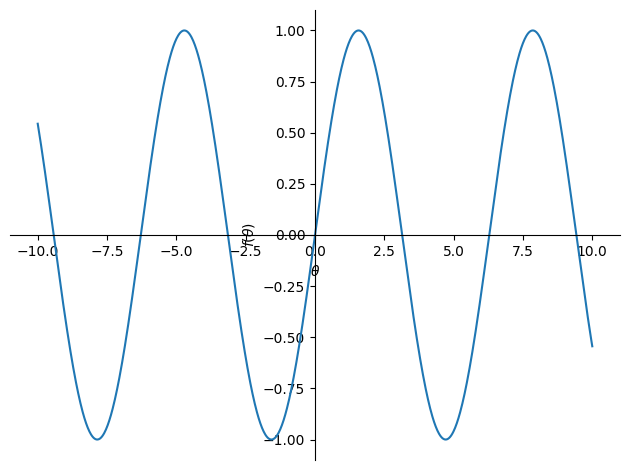

In [17]:
symplot(g)

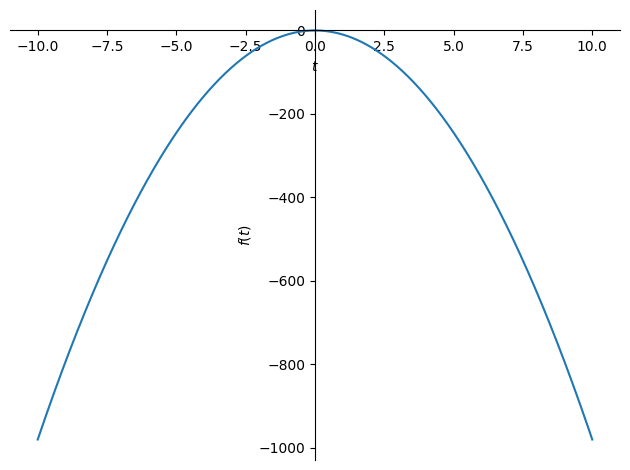

In [18]:
symplot(h)

# II. Single-Variable Calculus of Scalar Functions


Now that we can declare and manipulate scalar real-valued functions of a single variable, let's explore how to perform standard calculus operations on these functions. 

## II.A. Limits


### II.A.1 Limits of Continuous Functions



The _limit_ of a continuous scalar function $f(x)$, given by
$$\lim_{x\to a} f(x) = L,$$
means that as the scalar variable $x$ becomes arbitrarily close to the real value $a$, the output of the scalar function $f(x)$ becomes arbitrarily close to the real value $L$. To evaluate a limit in SymPy, use the `limit()` function:

:::{tip} 🐍 Limits in SymPy
:icon: false
To evaluate the limit
$$\lim_{x\to a} f(x) = L,$$
use the SymPy `limit()` function:
```{code}python
:linenos:
:filename:Syntax Demonstration
var('v', real=True) # Declare arbitrary real variable v
f =                 # Define the function f(v) here
limit(f, v, a)      # Directly substitute the value for a in here!
```
:::

:::{warning}⚒️ Your Turn
:icon: false
Determine the limit $L$ of the function $f(x) = x^3 - 3x + 15$ as $x$ approaches the following values $a$ by evaluating
\begin{equation*}
\lim_{x\to a} x^3 - 3x + 15
\end{equation*}
| Part | Value to Approach         |
|:----:|:-------------------------:|
| (1)  | $\displaystyle x\to 4.5$  |
| (2)  | $\displaystyle x\to 0$    |
| (3)  | $\displaystyle x\to -3.1$ |
:::

In [27]:
# Your Turn


In [9]:
# Your Turn: Part 1
limit(f,x,4.5)

92.6250000000000

In [10]:
# Your Turn: Part 2
limit(f,x,0)

15

In [11]:
# Your Turn: Part 3
limit(f,x,-3.1)

-5.49100000000000

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
For the function $f(x) = x^3 - 3x + 15$, you should have determined that 

| Part | $\displaystyle x\to a$    | Limit of $f(x)$        |
|:----:|:-------------------------:|:----------------------:|
| (1)  | $\displaystyle x\to 4.5$  | $\displaystyle 92.625$ |
| (2)  | $\displaystyle x\to 0$    | $\displaystyle 15$     |
| (3)  | $\displaystyle x\to -3.1$ | $\displaystyle -5.491$ |
:::

### II.A.2 Limits of Non-Continuous Functions


Certain functions are not "continuous" for some finite (or even infinite) number of possible input values (see {u}`[OSCv1 Section 2.4](https://openstax.org/books/calculus-volume-1/pages/2-4-continuity)` for a formal discussion). Three possible types of discontinuities are visualized in [](#fig-discontinuity-types) below.

:::{figure} https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260604.144757/resources/bbedfbc9abd13801b9da8dd62b424bb5c39768d4
:label:fig-discontinuity-types
:alt:Graphical depiction of the three types of discontinuities of a scalar function of a single variable. Left, label (a): a removable discontinuity; center, labeled (b): a jump discontinuity; right, labeled (c): an infinite discontinuity for which the left and right directional limits do not agree.
:align:center:
Graphical depiction of the three types of discontinuities of a scalar function of a single variable. (a) a removable discontinuity whose limit exists; (b) a jump discontinuity whose left and right directional limits are not equal; (c) an infinite jump discontinuity for which the left and right directional limits are not equal. (Image source: {u}`[OSCv1 Section 2.4](https://openstax.org/books/calculus-volume-1/pages/2-4-continuity)`)
:::

The value of a limit at these discontinuities depend on the type of discontinuity: 
* For a removable discontinuity (e.g., [](#fig-discontinuity-types).a), the limit exists and the value of the limit is what the value of the function "should" be if the discontinuity simply weren't there. 
* For a jump discontinuity (e.g., [](#fig-discontinuity-types).b & c), the limit does not exist, and we can only consider the limit as the function approaches the discontinuity from a certain direction (either from the left or right)

:::{tip}🐍 Directional Limits in SymPy
:icon:false
When the limit at a jump discontinuity (either finite or infinite) does not exist, we can instead speak about the _directional limit_ from either the left or the right:
| Direction      | Mathematical Notation               | SymPy Code         |
|:---------------|:------------------------------------|:-------------------|
| From the Left  | $\displaystyle\lim_{x\to a^-} f(x)$ | `limit(f,x,a,'-')` |
| From the Right | $\displaystyle\lim_{x\to a^+} f(x)$ | `limit(f,x,a,'+')` |
:::

:::{warning}⚒️ Your Turn
:icon: false
To see how to perform the directional limit of a scalar function at a discontinuity using SymPy, 
1. Define the real-valued function
$$m(x) = \frac{1}{x - 5}$$
2. Visualize $m(x)$ with `symplot()`
3. Predict the values of the left- and right-hand directional limits at the discontinuity $x=5$
4. Evaluate the left- and right-hand directional limits at $x=5$
5. Did your expectations match the directional limits evaluated by SymPy?
:::

In [28]:
# YOUR TURN: Directional Limits of m(x) = 1/(x-5) at x=5


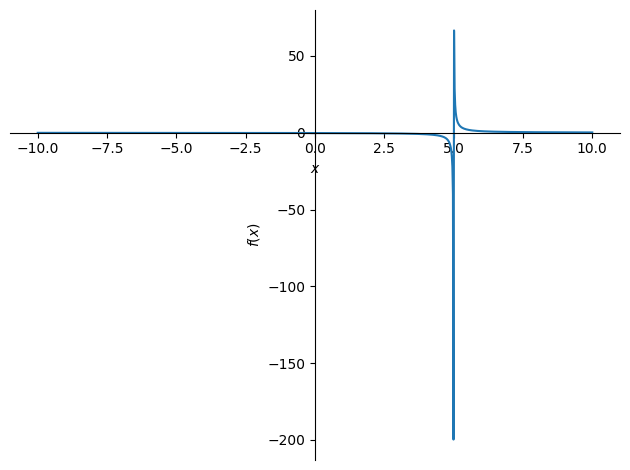

In [20]:
# YOUR TURN: Directional Limits of m(x) = 1/(x-5) at x=5
## Declare variable x and define function m(x)
var('x', real=True)
m = 1/(x-5)
## Plot m(x)
plot(m)

In [21]:
# YOUR TURN: Left-Hand Limit of m(x) @ x->5
limit(m,x,5,'-')

-oo

In [22]:
# YOUR TURN: Left-Hand Limit of m(x) @ x->5
limit(m,x,5,'+')

oo

:::{exercise} Directional Limits
Consider the function
$$n(x) = \frac{1}{\left\vert x-5\right\vert}$$
For each of the following questions, first (a) predict the behavior of $n(x)$ and then (b) test your predictions with SymPy to verify your understanding of limits.

1. What is the value of the left-hand limit of $n(x)$ as $x^-\to 5$?
2. What is the value of the right-hand limit of $n(x)$ as $x^+\to 5$?
3. Do the left- and right-hand directional limits have the same value?
4. Does the "proper" (i.e., non-directional) limit of $n(x)$ _exist_ as $x\to 5$?
:::{hint}💡 Hints
:icon:false
:class:dropdown
1. Remember, the absolute value function in both Python and SymPy is `abs()`
2. To test whether two SymPy expressions, (e.g., `expr1` & `expr2`) are mathematically equal in value, you can use
    ```python
    expr1.equals(expr2) # Will return True if they're equal and False if they're not
    ```
::::::

In [29]:
# YOUR TURN


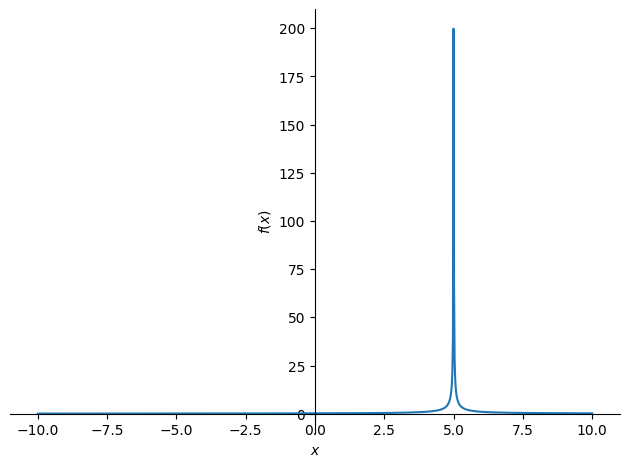

In [23]:
# SE2 Setup: Define n(x), plot if desired
var('x', real=True)
n = 1/abs(x-5)
symplot(n)

In [24]:
# SE2 Part 1: Left-hand limit of n(x)
limit(n,x,5,'-')

oo

In [25]:
# SE2 Part 2: Right-hand limit of n(x)
limit(n,x,5,'-')

oo

In [27]:
# SE2 Part 3: Do the directional limits match?
## Tip: Use limit(left).equals(limit(right)) to test for mathematical equality!
limit(n,x,5,'-').equals(limit(n,x,5,'-'))

True

:::{warning}⚒️ Your Turn: Predict 🧐 & Reflect 🪞
:icon: false
Consider the behavior of the _proper_ (non-directional) limits of the functions $m(x)$ and $n(x)$ as $x\to 5$. 
1. What do you expect the behavior of SymPy to be when evaluating them with `limit()`, without specifying any direction of approach?
2. Does the behavior of SymPy `limit()` function agree with your mathematical understanding of the limit?
3. Based on your response to the question above, recommend a set of steps to one of your peers for computing the limit of a general function $f(x)$ at some point $a$ that will return the _mathematically expected result_.
:::

In [30]:
# Scratch space for reflection


Double-click this cell & type your reflection below!
1. _Type your reflection here!_
2. _Type your reflection here!_
3. _Type your reflection here!_

### II.A.4 "Improper" Limits at Infinity



Very commonly, it is desirable to determine the behavior of a scalar function $f(x)$ as $x$ becomes either very large ($x\to\pm\infty$) or very small ($x\to O$). Determining the limiting behavior of $f(x)$ as $x$ becomes small in magnitude is typically a simple case of evaluating the limit of the function as $x\to 0$, however limits of scalar functions taken as their argument becomes infinitely large (also referred to as the function's _end behavior_) are more mathematically complicated (see, e.g., {u}`[OSCv1 section 4.6 🔗](https://openstax.org/books/calculus-volume-1/pages/4-6-limits-at-infinity-and-asymptotes)` for a more thorough discussion).

:::{note}ℹ️ Definition: Improper Limits
:icon:false
For the purposes of this lesson, we will say that
$$\lim_{x\to\pm\infty} f(x) = c$$
if as $x$ becomes sufficiently large in magnitude (either positive or negative), that $f(x)$ becomes close to $c$. 
:::

While long-hand determination of a function's end behavior can be challenging, doing so with SymPy is just as straightforward as doing so for a typical limit.

:::{tip} 🐍 Determining the End Behavior of a Function in SymPy
:icon: false
The end behavior of a function $f(x)$ in SymPy can be determined by
```{code}python
:linenos:
limit(f, x, oo)     # Limit as x approaches positive infinity
limit(f, x, -oo)    # Limit as x approaches negative infinity
```
:::{note} 👀 Tip: Representing Infinity in SymPy
:icon:false
To represent infinity ($\infty$) in SymPy, use the symbol `oo` (two lower-case letter "o"s).
::::::

:::{warning}⚒️ Your Turn
:icon: false
Use SymPy to determine the end behavior of the function
$$k(x) = \frac{5\sin{x}}{x}$$
as $x\to\infty$.
:::

In [31]:
# YOUR TURN: End behavior of k(x)


In [33]:
# YOUR TURN: End behavior of k(x)
k = (5* sin(x)) / x
limit(k, x, oo)

0

:::{warning} ✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that
\begin{equation*}
\lim_{x\to\infty} k(x) = 0
\end{equation*}

:::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving the example above should resemble the following:
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN: End behavior of k(x)
k = (5* sin(x)) / x
limit(k, x, oo)
```
```{code}txt
:filename:Cell Output
0
```
::::::

## II.B. Derivatives


### II.B.1 Evaluating Derivatives of a Scalar Function


:::{note}ℹ️ Definition: Derivative of a Scalar Function of a Single Variable
:icon:false
For a continuous scalar function $f(x)$ of a single variable, the _derivative_ of the function with respect to $x$ is given by
\begin{equation*}
\frac{d f}{d x} = \lim_{h\to 0}\frac{f(x + h) - f(x)}{h}
\end{equation*}
which is equivalently denoted $f'(x)$. The value of the derivative at a particular point $x_0$, denoted $f'(x_0)$, gives the _slope of a line tangent to the original function $f(x)$_. 
:::


The "limit definition" above is not typically used to evaluate derivatives in practice; rather, there are several "rules" for how to construct the derivative of a function depending on the algebraic form of the function's dependence on the independent variable (i.e., power, product, quotient, chain, etc.). While long-hand differentiation can become an onerous process as a function's form becomes more complicated, _every derivative_ can be evaluated in SymPy with exactly the same syntax.

:::{tip} 🐍 Evaluating the Derivative of a Function
:icon: false
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x', real=True) # Variable declaration
f =                 # Function definition placed here
d = diff(f, x)      # Evaluate the derivative of the function f with respect to th variable x
```
:::

:::{warning} ⚒️Your Turn
:icon: false
In the cells below, construct the derivatives of the functions $f(x)$, $g(\theta)$, and $h(t)$ that you defined earlier.
| Part | Scalar Function                          |
|:----:|:-----------------------------------------|
| (a)  | $\displaystyle f(x) = x^3 - 3x + 15$     |
| (b)  | $\displaystyle g(\theta) = \sin{\theta}$ |
| (c)  | $\displaystyle h(t) = -4.9t^2$           |
:::

In [32]:
# YOUR TURN


In [65]:
# Your Turn: Derivative of f(x) 
diff(f,x)

3*x**2 - 3

In [68]:
# Your Turn: Derivative of g(theta)
diff(g, theta)

cos(theta)

In [69]:
# Your Turn: Derivative of h(t)
diff(h, t)

-19.6*t

:::{warning} ✅ Check Yourself
:icon:false
:class:dropdown
You should have gotten the following derivatives from SymPy:
| Part | Scalar Function                          | Derivative                  |
|:-----|:-----------------------------------------|:----------------------------|
| (a)  | $\displaystyle f(x) = x^3 - 3x + 15$     | $\displaystyle 3x^2 - 3$    |
| (b)  | $\displaystyle g(\theta) = \sin{\theta}$ | $\displaystyle\cos{\theta}$ |
| (c)  | $\displaystyle h(t) = -4.9t^2$           | $\displaystyle -19.6t$      |
:::


Not only can we take the derivative using SymPy, we can also evaluate arbitrary-order ($n$th-order) derivatives, defined as repeatedly taking the first derivative $n$ times in sequence,
$$\frac{d^n}{dx^n} f = \frac{d}{dx}\left[\frac{d}{dx}\left[\frac{d}{dx}\left[\ldots\left[\frac{d}{dx} f\right]\right]\right]\right]$$
using exactly the same one-line Python syntax!

:::{tip} 🐍 Evaluating the $n$th Derivative of a Function
:icon: false
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x', real=True) # Variable declaration
f =                 # Function definition placed here
d = diff(f, x, n)   # Replace `n` with the desired order of the derivative to evaluate
```
:::


For example, the second derivative of $h(t)$, denoted $h''(t)$, is given by
$$h''(t) = \frac{d^2}{dx^2} h(t) = \frac{d}{dt}\left[\frac{d}{dt} h(t)\right] = \frac{d}{dt}\left[-19.6 t\right] = -19.6,$$
which we can evaluate with one line of Python as `diff(h, t, 2)`.

:::{warning}⚒️ Your Turn
:icon: false
In the cell below, verify that the second derivative of $h(t)$ is indeed $h''(t) = -19.6$ by evaluating the second derivative with SymPy.
:::

In [33]:
# YOUR TURN: Verify that h''(t) = -19.6


In [72]:
# YOUR TURN: Verify that h''(t) = -19.6
diff(h,t,2)

-19.6000000000000

### II.B.2 Logarithmic and Exponential Functions


In physics and chemistry, two special classes of functions that are encountered particularly often are exponential functions and logarithmic functions. As it turns out, these two classes of functions are the _inverse_ of each other --- just like division can "undo" multiplication and visa versa, taking the logarithm and the exponential of a quantity are inverse operations that cancel each other out (provided they are operating with the same _base_). 

For example, when considering acid/base equilibria at the chemistry level, we defined the ${\rm pH}$ as the negative common logarithm (i.e., base-10) of the hydronium concentration:
$${\rm pH} = -\log_{10}{\left[{\rm H_3O^+}\right]}$$
which can be rearranged for $\left[{\rm H_3O^+}\right]$ by taking the inverse of the common logarithm of both sides of the expression:
$$10^{\rm -pH} = \left[{\rm H_3O^+}\right].$$

In the same way, the natural logarithm $\ln{x} = \log_{e}{x}$, whose base is the natural number $e$, has the exponential function $\exp{x}$ as its inverse. Before moving on to explore the calculus of logarithmic and exponential functions, recall that coding languages like Python represent logarithms in a different way than is typical in longhand mathematics

::::{danger}☢️ Danger: Logarithms in Python
:icon:false
Unlike in a normal mathematical context, where "$\log$" is understood to represent the common logarithm and "$\ln$" is understood to mean the natural logarithm, Python and many other programming languages actually use `log` to mean the natural logarithm and `log10` to mean the common logarithm. 

Because this and future lessons involve both the numerical evaluation and symbolic manipulation of the natural & common logarithms, the logarithm functions from two separate libraries have been imported into this notebook in the {u}`[Package Imports](#package-imports)` section, summarized below:

|                                                                       | Natural Logarithm | Common Logarithm |
|:----------------------------------------------------------------------|:-----------------:|:----------------:|
| Base                                                                  | $e$               | $10$             |
| Mathematical notation                                                 | $\ln{x}$          | $\log{x}$        |
| Function from the `math` Library (standalone numerical evaluation)    | `mlog()`          | `mlog10()`       |
| Function from the `sympy` Library (symbolic manipulations & calculus) | `sylog()`         | `sylog10()`      |

:::{tip}🐍 Import Aliases for Logarithmic Functions
:icon:false
:class:dropdown
In both the `math` and `sympy` libraries, the natural and common logarithm functions have identical names. To avoid name clashes, these functions were imported in {u}`[Package Imports](#package-imports)` section, with the aliases tabulated above defined on lines 5-6 and 11-12 (highlighted below): 
```{code}python
:linenos:
:filename:Python Input
:emphasize-lines: 5,6,11,12
# EXECUTE: Import some packages that we will use later
from algebra_with_sympy import * # Automatically imports sympy
algwsym_config.output.solve_to_list = True # Makes automatic solution outputs a list for usability
import math
from math import log as mlog
from math import log10 as mlog10
import numpy as np
import scipy as sp
from sympy.plotting import plot as symplot
from IPython.display import display, Markdown
from sympy.functions.elementary.exponential import log as sylog
from sympy.codegen.cfunctions import log10 as sylog10
print(f"This notebook is running Algebra_with_Sympy version {str(algwsym_version)}.")
```
:::
::::


Much like the derivatives of trigonometric functions (e.g., $\sin{x}$, $\cos{x}$, etc.), the derivatives of logarithmic and exponential functions have their own definitions different from the power rule for polynomials. 

:::{note}ℹ️ Definition: Derivatives of General Exponential Functions
:icon:false
For a general exponential function
$$f(x) = C\ b^{u(x)},$$
where $C$ is a constant (scalar) prefactor, $b$ is any real number (referred to as the _base_ of the exponential), and $u(x)$ is a real-valued scalar function of $x$, the derivative $f'(x)$ is defined as
$$f'(x) = \frac{d}{dx} C\ b^{u(x)} = C\ b^{u(x)}\ u'(x)\ \ln{b}$$
:::

This definition has the interesting consequence that the function $f(x) = e^x$ is unchanged by taking the derivative:
$$\frac{d}{dx} e^x = e^x\cdot\ln{e} = e^x$$
becuase $\ln{e} = 1$. 

:::{note}ℹ️ Definition: Derivatives of General Logarithmic Functions
:icon:false
For a general logarithmic function
$$f(x) = C\ \log_b{\left[ u(x)\right]}$$
where the prefactor $C$ is a real number, $b$ is any real number (referred to as the _base_ of the logarithm), and $u(x)$ is a real-valued scalar function of $x$, then for any value of $u(x)>0$, the derivative $f'(x)$ is defined as 
$$f'(x) = C\times\frac{u'(x)}{u(x)\ \ln{b}}$$
:::

For the natural logarithmic function $\ln{x}$ specifically, the definition above means that
$$\frac{d}{dx}\ln{x} = \frac{1}{x\cdot\ln{e}} = \frac{1}{x}.$$
Fortunately, taking derivatives of logarithmic and exponential functions in SymPy is just as straightforward as any other function!

:::{warning}⚒️ Your Turn
:icon: false
In the cells below, evaluate the first and second derivatives of each of the following exponential & logarithmic functions.

| Part | Function | 
|:----:|:--------:|
| (1)  | $\displaystyle f(x) = e^{2x^2}$ |
| (2)  | $\displaystyle g(x) = \ln{\frac{x^2}{2x+1}}$ |
| (3)  | $\displaystyle h(x) = \log{\left(e^{x^2}\right)}$ |

:::{hint}💡 Hints
:icon:false
:class:dropdown
1. Particularly for exponential and logarithmic functions, it's critical to declare that your math variables are real numbers!
2. The exponential function $e^x$ is represented in SymPy as `exp(x)`
3. If your derivative looks way more complicated than the answer provided in the "✅ Check Yourself" drop-down key, try using the `Equation.simplify()` method to clean it up:
    ```{code}python
    :linenos:
    :filename:Demonstration of the Equation.simplify() method
    var('x', real=True)
    f =                # function definition goes here!
    fprime = diff(f,x) # evaluating the derivative
    fprime.simplify()  # Clean up the expression for the derivative to help compare to key
::::::

In [35]:
# YOUR TURN


In [29]:
# YOUR TURN: Part 1
var('x',real=True)
f = exp(2*x**2)
df = diff(f,x).simplify()
ddf = diff(f,x,2).simplify()
display(df)
display(ddf)

4*x*exp(2*x**2)

(16*x**2 + 4)*exp(2*x**2)

In [30]:
# YOUR TURN: Part 2
var('x',real=True)
g = log((x**2) / (2*x + 1))
dg = diff(g,x).simplify()
ddg = diff(g,x,2).simplify()
display(dg)
display(ddg)

2*(x + 1)/(x*(2*x + 1))

2*(-2*x**2 - 4*x - 1)/(x**2*(4*x**2 + 4*x + 1))

In [31]:
# YOUR TURN: Part 3
var('x', real=True)
h = sylog10(exp(x**2))
dh = diff(h,x).simplify()
ddh = diff(h,x,2).simplify()
display(dh)
display(ddh)

2*x/log(10)

2/log(10)

:::{warning} ✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that for the functions above, their first and second derivatives are:
| Part | Function | 1{sup}`st` Derivative | 2{sup}`nd` Derivative |
|:----:|:--------:|:---------------------:|:---------------------:|
| (1)  | $\displaystyle f(x) = e^{2x^2}$  | $\displaystyle f'(x) = 4 x e^{2 x^{2}}$ | $\displaystyle f''(x) = \left(16 x^{2} + 4\right) e^{2 x^{2}}$ |
| (2)  | $\displaystyle g(x) = \ln{\frac{x^2}{2x+1}}$ | $\displaystyle g'(x) = \frac{2 \left(x + 1\right)}{x \left(2 x + 1\right)}$ | $\displaystyle g''(x) = \frac{2 \left(- 2 x^{2} - 4 x - 1\right)}{x^{2} \left(4 x^{2} + 4 x + 1\right)}$ |
| (3)  | $\displaystyle h(x) = \log{\left(e^{x^2}\right)}$ | $\displaystyle h'(x) = \frac{2 x}{\log{\left(10 \right)}}$ | $\displaystyle h''(x) = \frac{2}{\log{\left(10 \right)}}$ |
:::

### II.B.3 Trigonometric Functions


Particularly for physical chemistry applications to the quantum mechanics of atomic and molecular systems, trigonometric functions are extremely common. Unlike exponential and logarithmic functions whose representations in mathematics and code are different, trigonometric functions are exactly the same in SymPy as in regular mathematics. 

:::{note}ℹ️ Definition: Derivatives of Trigonometric Functions
:icon:false
The derivatives of the six trigonometric functions are as follows:

| Trig. Function | Derivative |
|:--------------:|:-----------|
| $\displaystyle \sin{x}$ | $\displaystyle \frac{d}{dx}\sin{x} = \cos{x}$ |
| $\displaystyle \cos{x}$ | $\displaystyle \frac{d}{dx}\cos{x} = -\sin{x}$ |
| $\displaystyle \tan{x}$ | $\displaystyle \frac{d}{dx}\tan{x} = \sec^2{x}$ |
| $\displaystyle \cot{x}$ | $\displaystyle \frac{d}{dx}\cot{x} = -\csc^2{x}$ |
| $\displaystyle \sec{x}$ | $\displaystyle \frac{d}{dx}\sec{x} = \sec{x}\tan{x}$ |
| $\displaystyle \csc{x}$ | $\displaystyle \frac{d}{dx}\csc{x} = -\csc{x}\cot{x}$ |
:::

:::{tip}🐍 Trigonometric Functions in SymPy
:icon:false
To encode a mathematical expression depending on any of the trigonometric functions, simply call their function from SymPy. 

For example, the function
\begin{equation*}
f(x) = \frac{\sin{x}}{1-\cot^2{x}}
\end{equation*}
can be encoded with the following syntax:
```{code}python
:linenos:
:filename:Syntax Demonstration: Trig Functions in SymPy
var('x', real=True)
f = sin(x) / (1 - cot(x)**2)
```
:::

:::{warning}⚒️ Your Turn
:icon:false
Evaluate the requested derivative of the following functions of a real variable $x > 0$.

| Part | Function | Derivative |
|:----:|:--------:|:----------:|
| (1)  | $\displaystyle f(x) = \cot^2{x}$ | $\displaystyle \frac{d}{dx} f(x)$ |
| (2)  | $\displaystyle f(x) = \sin{x}\tan{x}$ | $\displaystyle \frac{d^2}{dx^2} f(x)$ |
| (3)  | $\displaystyle f(x) = \cos{\sqrt{x}}$ | $\displaystyle \frac{d^3}{dx^3} f(x)$ |
:::

In [36]:
# YOUR TURN


In [14]:
# YOUR TURN
## Declare variables, define function
var('x', real=True, positive=True, nonzero=True)
fns = [cot(x)**2, sin(x)*tan(x), cos(sqrt(x))]

## Evaluate derivatives
for i, f in enumerate(fns):
    print(i+1)
    df = diff(f,x,i+1).expand().simplify()
    display(df)
    print(latex(df))

1


-2*cot(x)/sin(x)**2

- \frac{2 \cot{\left(x \right)}}{\sin^{2}{\left(x \right)}}
2


(sin(x)**4 + cos(x)**2 + 1)/cos(x)**3

\frac{\sin^{4}{\left(x \right)} + \cos^{2}{\left(x \right)} + 1}{\cos^{3}{\left(x \right)}}
3


(x**(9/2)*sin(sqrt(x)) - 3*x**(7/2)*sin(sqrt(x)) + 3*x**4*cos(sqrt(x)))/(8*x**6)

\frac{x^{\frac{9}{2}} \sin{\left(\sqrt{x} \right)} - 3 x^{\frac{7}{2}} \sin{\left(\sqrt{x} \right)} + 3 x^{4} \cos{\left(\sqrt{x} \right)}}{8 x^{6}}


:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that, after simplification, the requested derivatives of the functions are given by

| Part | Function | Derivative |
|:----:|:---------|:-----------|
| (1)  | $\displaystyle f(x) = \cot^2{x}$ | $\displaystyle \frac{d}{dx} f(x) = - \frac{2 \cot{\left(x \right)}}{\sin^{2}{\left(x \right)}}$ |
| (2)  | $\displaystyle f(x) = \sin{x}\tan{x}$ | $\displaystyle \frac{d^2}{dx^2} f(x) = \frac{\sin^{4}{\left(x \right)} + \cos^{2}{\left(x \right)} + 1}{\cos^{3}{\left(x \right)}}$ |
| (3)  | $\displaystyle f(x) = \cos{\sqrt{x}}$ | $\displaystyle \frac{d^3}{dx^3} f(x) = \frac{x^{\frac{9}{2}} \sin{\left(\sqrt{x} \right)} - 3 x^{\frac{7}{2}} \sin{\left(\sqrt{x} \right)} + 3 x^{4} \cos{\left(\sqrt{x} \right)}}{8 x^{6}}$ |
:::

### II.B.4 Application: Instanteous Rate of Change


Calculus is not just a field of interest for its own sake, but also has wide applications throughout the physical and life sciences. To see this in the context of the operation of differentiation and the derivative of a function, let's explore a few of the derivative's most common applications in introductory science courses.


The slope of a line intersecting a curve $f(x)$ at two points $x=a$ and $x=b$ (called a _secant line_) represents the _average rate of change_ for the function over the interval $[a,b]$, whereas the slope of a _tangent line_ which only intersects the curve $f(x)$ at _exactly one point_ represents the _instantaneous_ rate of change in the function $f$ at that point.  Because the derivative of a function returns the slope of the tangent line, derivatives can be interpreted as representing the instantaneous change of a function. 


To see how this concept can be applied in the sciences, let's imagine a projectile launched vertically from ground level with some instantaneous velocity. The height of the projectile is a function of time, $h(t)$, whose derivative represents the instantaneous rate of change in the position of the projectile as a function of time --- in other words, the velocity of the projectile! Similarly, the second derivative represents the instantaneous rate of change of the velocity --- i.e., the projectile's acceleration!

:::{warning}⚒️ Your Turn
:icon:false
Consider a projectile launched vertically from ground level, whose height as a function of time is given by
\begin{equation*}
h(t) = -4.9 t^2 + 6.5t
\end{equation*}
In the cell below, determine the instantaneous velocity and instantaneous acceleration of a projectile launched upwards from the Earth's surface after (a) 0 seconds have elapsed (i.e., the _initial_ velocity and acceleration) and (b) after 3 seconds of time have elapsed. 
:::

In [37]:
# YOUR TURN: Determine instantaneous velocity & acceleration at t = 3 seconds 


In [20]:
# Your Turn: Determine instantaneous velocity & acceleration at t = 3 seconds 
## Declare time variable & height function
var('t', real=True)
h = -4.9*t**2 + 6.5*t

## Determine velocity function & instantaneous value @ t = 3 seconds
v = diff(h,t)
v_3s = v.subs({t:3})
v_0s = v.subs({t:0})

## Determine acceleration function & instantaneous value @ t = 3 seconds
a = diff(h,t,2)
a_0s = a.subs({t:0})
a_3s = a.subs({t:3})

print(f'Initial velocity: v = {v_0s:4.2f} m/s')
print(f'Velocity after 3 seconds: v = {v_3s:4.2f} m/s')
print(f'Initial accelleration: a = {a_0s:4.2f} m/s^2')
print(f'Acceleration after 3 seconds: a = {a_3s:4.2f} m/s^2')

Initial velocity: v = 6.50 m/s
Velocity after 3 seconds: v = -22.90 m/s
Initial accelleration: a = -9.80 m/s^2
Acceleration after 3 seconds: a = -9.80 m/s^2


:::{warning} ✅ Check Yourself
:icon:false
:class:dropdown
You should have determined for this particle that
| Time Elapsed, $t$ (${\rm s}$) | Velocity, $v$ (${\rm m\cdot s^{-1}}$) | Acceleration, $a$ (${\rm m\cdot s^{-2}}$) |
|:-----------------------------:|:-------------------------------------:|:-----------------------------------------:|
| $\displaystyle t = 0 {\rm\ s}$ | $\displaystyle v_0 = 6.50 {\rm\ m\cdot s^{-1}}$ | $\displaystyle a_0 = -9.80 {\rm\ m\cdot s^{-2}}$ |
| $\displaystyle t = 3 {\rm\ s}$ | $\displaystyle v_3 = -22.90 {\rm\ m\cdot s^{-1}}$ | $\displaystyle a_3 = -9.80 {\rm\ m\cdot s^{-2}}$ |

:::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving the example above should resemble the following:
```{code}python
:linenos:
:filename:Python Input
# Your Turn: Determine instantaneous velocity & acceleration at t = 3 seconds 
## Declare time variable & height function
var('t', real=True)
h = -4.9*t**2 + 6.5*t

## Determine velocity function & instantaneous value @ t = 3 seconds
v = diff(h,t)
v_3s = v.subs({t:3})
v_0s = v.subs({t:0})

## Determine acceleration function & instantaneous value @ t = 3 seconds
a = diff(h,t,2)
a_0s = a.subs({t:0})
a_3s = a.subs({t:3})

print(f'Initial velocity: v = {v_0s:4.2f} m/s')
print(f'Velocity after 3 seconds: v = {v_3s:4.2f} m/s')
print(f'Initial accelleration: a = {a_0s:4.2f} m/s^2')
print(f'Acceleration after 3 seconds: a = {a_3s:4.2f} m/s^2')
```
```{code}txt
:filename:Cell Output
Initial velocity: v = 6.50 m/s
Velocity after 3 seconds: v = -22.90 m/s
Initial accelleration: a = -9.80 m/s^2
Acceleration after 3 seconds: a = -9.80 m/s^2
```
::::::

## II.C. Integrals



Integration is an extremely important mathematical tool for describing a great deal of physical phenomena and their properties, however the rigorous mathematical treatment of integration necessary to effectively integrate by hand is extremely laborious. Alternatively, evaluating integrals either symbolically using the SymPy library or numerically using the SciPy library is nearly trivial by comparison. Because this lesson is primarily concerned with supporting students' development of the cyberinfrastructure skills for performing calculus operations in Python, we will limit our discussion here to a practical introduction to methods of integration in Python rather than a lengthy review of integral calculus.


Because this section of the lesson will discuss both symbolic integration with SymPy and a numerical approach using the SciPy library, we first review some basic mathematical definitions related to integration before moving onto discussing these methods of integration in Python.

### II.C.1 Riemann Summation


Many physical problems require that we determine the area under a curve, as illustrated exactly in [Fig. %s](#sfig:defint) below:

:::{figure}
:label:fig:riemann-vs-defint
:align:center
:alt:A figure with two horizontally aligned subfigures, comparing the Riemann sum (left) versus the definite integral (right) for computing the area under a downward-facing parabola over the closed interval [0,2]. Subfigure A (left): A graph of a downward opening parabola over [-1, 2] with vertex at (0,2) and x-intercepts at (-1,0) and (1,0). Eight rectangles are drawn evenly over [0,2] with heights determined by the value of the function at the left endpoints of each. The rectangles with positive area in the interval [0,1] overestimate the area under the parabola, and the rectangles with negative area in the interval [1,2] underestimate the area under the parabola. Subfigure B (right) A graph of a downward opening parabola over [-2, 2] with vertex at (0,2) and x-intercepts at (-1,0) and (1,0). The area in quadrant one under the curve is shaded blue and labeled A1. The area in quadrant four above the curve and to the left of x=2 is shaded blue and labeled A2.
:class: grid grid-cols-2 items-end gap-4
(sfig:riemann)=
![Illustration of the left-hand Riemann sum for the area under a curve.](https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260604.144757/resources/e40f3685ba10d7ea1160a847eb812a6df35c50ff)
(sfig:defint)=
![Illustration of the definite integral for the area under a curve.](https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260604.144757/resources/7650bcbf889bf0d02768eafb775ab9eef3de7337)

Computing the area under a parabola via the Riemann sum (left) versus the definite integral (right). Image source: {u}`[OSCv1 Section 5.2](https://openstax.org/books/calculus-volume-1/pages/5-2-the-definite-integral)`.
:::


Without yet knowing how to do compute this quantity, however, we can approximate the area under the curve by accumulating areas we _do_ know how to compute, e.g., rectangles.

:::{note}ℹ️ Definition: Riemann Sum for the Area Under a Curve
:icon:false
The area $A$ under a curve $f(x)$ can be computed approximately by accumulating the area of a finite number of rectangles, each of area $A_i = w\times h_i$, as illustrated in [Fig. %s](#sfig:riemann) above:
\begin{equation}
A \approx \sum_{i=1}^N \Delta x\ f(x_i^{\ast})
\label{eqn:riemann-area}
\end{equation}
where $\Delta x = x_i - x_{i-1}$ is the uniform rectangle width and $x_i^{\ast}$ is any point along the sub-interval $[x_{i-1},x]$ at which the height of the rectangle is determined by evaluating the function $f(x)$. 
:::


Common choices for the points $x_i^{\ast}$ in the Riemann summation are given below:


| Choice of $x_i^{\ast}$               | Description                                            | Approximation Name           |
|:------------------------------------:|:-------------------------------------------------------|:-----------------------------|
| $\displaystyle x_i^{\ast} = x_{i-1}$ | Left endpoint of the interval $[x_{i-1},x]$            | Left-Endpoint Approximation  |
| $\displaystyle x_i^{\ast} = x_{i}$   | Right endpoint of the interval $[x_{i-1},x]$           | Right-Endpoint Approximation |
| $\displaystyle x_i^{\ast} = \frac{x_{i-1} + x_i}{2}$ | Midpoint of the interval $[x_{i-1},x]$ | Midpoint Approximation       |


Clearly, the area under the parabola in [Fig. %s](#sfig:riemann) as captured by the finite Riemann sum is flawed; some rectangles overestimate the area under the curve, while others underestimate the area. While it is possible to mitigate this error for an identical number of intervals by either using the midpoint approximation or by accumulating the area of a different shape entirely (trapezoids are a better choice than rectangles), a Riemann sum will _always_ be approximate for a finite number of intervals. 

:::{warning}⚒️ Your Turn: Area Under a Curve via Riemann Summation
:icon:false
Approximate the area under the curve $f(x) = 62.4x\left(8-\frac{8x}{3}\right)$ over the closed interval $0\leq x\leq 3$ with a Riemann sum of five rectangles using 
1. the right endpoint approximation,
2. the left endpoint approximation, and
3. the midpoint approximation.

Which approximation yields a Riemann sum which most accurately reproduces the actual area $A = 748.8$?
:::

In [38]:
# YOUR TURN: OSCv1 Sec 5.1 Ex 5.4


In [76]:
# OSCv1 Sec 5.1 Ex 5.4
var('x',real=True)
f = 62.4*x*(8 - (8*x)/3)
a = 0
b = 3
w = b-a
nrect = 5
dx = w / nrect

lxi = [a + i*dx for i in range(nrect)]
flxi = [f.subs({x:l}) for l in lxi]
rxi = [l + dx for l in lxi]
frxi = [f.subs({x:r}) for r in rxi]
mxi = [lxi[i] + (rxi[i] - lxi[i])/2 for i in range(nrect)]
fmxi = [f.subs({x:m}) for m in mxi]


larea = marea = rarea = 0
for i in range(nrect):
    left = a + i * dx
    larea += f.subs({x:left}) * dx
    right = left + dx
    rarea += f.subs({x:right}) * dx
    mid = left + (right - left) / 2
    marea += f.subs({x:mid}) * dx

print(f"Left = {larea:6.4f}, Middle = {marea:6.4f}, Right = {rarea:6.4f}")

Left = 718.8480, Middle = 763.7760, Right = 718.8480


### II.C.2 Fundamental Theorem of Calculus

What if we actually want the _exact_ area, as in [Fig. %s](#sfig:defint)?

:::{note}ℹ️ Definition: Definite Integral of a Continuous Function
:icon:false
Let $f(x)$ be a continuous function on the interval $[a,b]$. The area under the curve $f(x)$ is given by the _definite integral_
\begin{equation}
A = \int_a^b dx\ f(x) = \lim_{\substack{N\to\infty\\ \Delta x\to 0}}\sum_{i=1}^N \Delta x\ f(x_i^{\ast})
\label{eqn:definite-integral-defn}
\end{equation}
where the manner in which the summation is allowed to become infinite is by decreasing the width of the rectangles, i.e., $\Delta x\to 0$.
:::


While the definite integral fixes the approximation errors made in the Riemann sum by making the rectangles (or indeed any shape) infinitely narrow, it seems that this form of the definite integral would be impossibly difficult (or at least _really_ annoying!) to compute in practice. Fortunately, however, we may exploit the relationship between integration and differentiation given by the Fundamental Theorem of Calculus to make our life easier!

:::{note}ℹ️ The Fundamental Theorem of Calculus
:icon:false
Let $f(x)$ be a continuous function over the closed interval $[a,b]$. 
1. The _antiderivative_ $F(x)$ of the function $f(x)$ is given by the _indefinite_ integral
    \begin{equation}
    F(x) = \int dx\ f(x)
    \label{eqn:antiderivative}
    \end{equation}
    such that
    \begin{equation*}
    \frac{d}{dx} F(x) = F'(x) = f(x)
    \end{equation*}
2. The definite integral of the function $f(x)$ over the interval $[a,b]$ can be evaluated as
    \begin{equation}
    \int_a^b dx\ f(x) = F(x)\bigg\vert_a^b =  F(b) - F(a)
    \label{eqn:fundy-defint}
    \end{equation}
    where $F(x)$ is the antiderivative of the function $f(x)$.
:::

:::{warning}⚒️ Your Turn
:icon:false
Consider the function $v(t) = -19.6t + 3$, whose antiderivative over the interval $0\leq t\leq 10$ is given by $h(t) = -9.8t^2 + 3t$. 
1. Show that the function $v(t)$ is equal to the derivative of $h(t)$
2. Using [Eqn. %s](#eqn:fundy-defint), evaluate the definite integral
    \begin{equation*}
    \int_0^{10} dt\ v(t) = \int_0^{10} dt\ \left(-19.6t + 3\right)
    \end{equation*}
:::

In [39]:
# YOUR TURN: Assess & use fundamental theorem of calculus


In [84]:
# YOUR TURN: Assess & use fundamental theorem of calculus
## Declare variable & defined functions
var('t', real=True)
v = -19.6*t + 3
h = -9.8*t**2 + 3*t

## Part 1
hprime = diff(h,t)
print(f"Does the time derivative of h(t) equal v(t)? {hprime.equals(v)}")

## Part 2
val = h.subs({t:10}) - h.subs({t:0})
print(f"The definite integral of v(t) over [0,10] is equal to {val:6.1f}")

Does the time derivative of h(t) equal v(t)? True
The definite integral of v(t) over [0,10] is equal to -950.0


In [80]:
integrate(v,(t,0,10))

-950.000000000000

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that the derivative of $h'(t)$ does indeed equal the function $v(t)$, and the definite integral of $v(t)$ evaluates as
\begin{equation*}
\int_0^{10} dt\ v(t) = \int_0^{10} dt\ \left(-19.6t + 3\right) = -950.0
\end{equation*}
:::{hint}🐍 Code Key
:icon:false
:class:dropdown
Your code solving the example should resemble the following:
```{code}python
:linenos:
:filename:Code Input
# YOUR TURN: Assess & use fundamental theorem of calculus
## Declare variable & defined functions
var('t', real=True)
v = -19.6*t + 3
h = -9.8*t**2 + 3*t

## Part 1
hprime = diff(h,t)
print(f"Does the time derivative of h(t) equal v(t)? {hprime.equals(v)}")

## Part 2
val = h.subs({t:10}) - h.subs({t:0})
print(f"The definite integral of v(t) over [0,10] is equal to {val:6.1f}")
```
```{code}txt
:filename:Cell Output
Does the time derivative of h(t) equal v(t)? True
The definite integral of v(t) over [0,10] is equal to -950.0
```
::::::


While this example illustrates the connection between integration and differentiation, [Eqn. %s](#eqn:fundy-defint) seems for now to only be useful if the antiderivative $F(x)$ is _already_ known. Manually determining the antiderivative of a function by long-hand integration is a complicated proposition, and determining which of the wide range of potential strategies will be most effective is occasionally more of an art than a science.[^fn:osc-techniques-of-integration]

[^fn:osc-techniques-of-integration]: For a survey of long-hand techniques of integration, refer to Sections 1.5-1.7 of {u}`[OSCv2 Chapter 1](https://openstax.org/books/calculus-volume-2/pages/1-introduction)` and the entirety of {u}`[OSCv2 Chapter 3](https://openstax.org/books/calculus-volume-2/pages/3-introduction)`.

### II.C.3 Symbolic Integration with SymPy


Fortunately, the SymPy library has the capability to symbolically evaluate both indefinite and definite integrals of functions, even when a definite integral actually evaluates to a numerical answer. 

#### II.C.3.i Antiderivatives & Indefinite Integrals

:::{tip} 🐍 The Antiderivative of a Scalar Function
:icon:false
To determine the antiderivative $F(x)$ of a function $f(x)$ in SymPy, the indefinite integral
$$F(x) = \int dx\ f(x),$$
can be performed using the syntax
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x', real=True)         # Variable declaration
f =                         # Function definition placed here
antideriv = integrate(f, x) # First argument: function name (or expression), second argument: variable of integration
```
:::{warning}⚠️ Warning: Constants of Integration
:icon:false
For indefinite integrals, SymPy returns the antiderivative itself, i.e., without a constant of integration!
::::::

:::{warning}⚒️ Your Turn
:icon: false
In the cell below, 
1. Define the function $f(x) = x^2 - 3x + 5$
2. Evaluate the antiderivative $F(x)$ of $f(x)$
3. Show by differentiation that the derivative of $F(x)$ is identical to the original function $f(x)$.
:::

In [40]:
# YOUR TURN: Evaluate the antiderivative of a function with SymPy


In [90]:
# YOUR TURN: Evaluate the antiderivative of a function with SymPy
var('x', real=True)
f = x**2 - 3*x + 5
display(f)
F = integrate(f,x)
display(F)
Fprime = diff(F, x)
display(Fprime)
print(f"Does the derivative F'(x) equal the original function f(x)? {Fprime.equals(f)}")

x**2 - 3*x + 5

x**3/3 - 3*x**2/2 + 5*x

x**2 - 3*x + 5

Does the derivative F'(x) equal the original function f(x)? True


:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that the antiderivative of the function $f(x) = x^2 - 3x + 5$ is
\begin{equation*}
F(x) = \int dx\ f(x) = \int dx\ \left(x^2 - 3x + 5\right) = \frac{x^3}{3} - \frac{3x^2}{2} + 5x
\end{equation*}
whose derivative is
\begin{equation*}
F'(x) = \frac{d}{dx}F(x) = \frac{d}{dx}\left(\frac{x^3}{3} - \frac{3x^2}{2} + 5x\right) = x^2 - 3x + 5,
\end{equation*}
such that indeed $F'(x) = f(x)$.
:::

#### II.C.3.ii Definite Integrals

:::{tip} 🐍 Definite Integrals in SymPy
:icon:false
The definite integral may be evaluated mathematically according to the Fundamental Theorem of Calculus:
$$\int_a^b dx\ f(x) = F(x)\bigg\vert_a^b = F(b) - F(a),$$
which can be executed in SymPy as
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x a b', real=True) # Variable declaration: independent variable x, integration bounds a, b
f =                     # Function definition placed here
integrate(f, (x, a, b)) # Evaluates definite integral with respect to x over interval [a, b] 
```
:::

:::{warning}⚒️ Your Turn
:icon: false
In the cell below, define the function $f(x) = x^2 - 3x + 5$, and evaluate its definite integral over the bounds [-5, 5].
:::

In [41]:
# YOUR TURN: Evaluate the definite integral of x**2 - 3*x + 5 over [-5, 5]


In [93]:
# YOUR TURN: Evaluate the definite integral of x**2 - 3*x + 5 over [-5, 5]
var('x', real=True)
f = x**2 - 3*x + 5
integrate(f, (x, -5, 5))

400/3

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that the definite integral in this example evaluates to
\begin{equation*}
\int_{-5}^5 dx\ \left(x^2 - 3x + 5\right) = \frac{400}{3} = 133.\overline{33}
\end{equation*}

#### Exercise

:::{exercise} Ugly Definite Integrals
:label:ex:ugly-symbolic-definite-integration
Consider the trial function
\begin{equation*}
f(x) = e^{-\frac{1}{2}(x-\tfrac{1}{2})^2}.
\end{equation*}
For each of the functions $\{\psi_n(x)\}_{n=1}^3$, evaluate the definite integrals
\begin{equation*}
c_n = \int_0^1 dx\ f(x)\psi_n(x),
\end{equation*}
where each $\psi_n(x)$ is defined as
\begin{equation*}
\psi_n(x) = \sqrt{2}\sin{n\pi x}\;\;\; n = 1, 2, 3 {\rm\ (nonzero\ positive\ integer)}
\end{equation*}
:::{hint}💡 Hint: Float Evaluation
:icon:false
Some functions have no closed-form antiderivative, and SymPy will by default return an unevaluated integral expression even if a definite integral has been requested. To evaluate the numerical value of such an integral, call the `.evalf()` method on the expression returned by the `integrate()` function, i.e.,
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x a b', real=True)            # Variable declaration: independent variable x, integration bounds a, b
ugly =                             # Function with a non-elementary antiderivative
integrate(ugly, (x, a, b)).evalf() # Specifically request that integral be evaluated to a floating-point number
::::::

In [42]:
# YOUR TURN: Solve the exercise above!


In [136]:
# YOUR TURN: Solve the exercise above!
## Declare variables & define functions
var('x', real=True, positive=True, nonzero=True)
var('n', integer=True, positive=True, nonzero=True)
f = exp(-((x-1/2)**2)/2)
psi_n = sqrt(2)*sin(n*pi*x)

## Loop over n values, compute c_n, store to list
nvals = [1,2,3]
for nval in nvals:
    print(f"Evaluaing integral for n={nval}...")
    cn = float(integrate(f*psi_n.subs({n:nval}), (x, 0, 1)).evalf())
    print(f"\t c_{nval} = {cn}")

Evaluaing integral for n=1...
	 c_1 = 0.8795392654146708
Evaluaing integral for n=2...
	 c_2 = 1.7031839360032603e-108
Evaluaing integral for n=3...
	 c_3 = 0.2671325593154089


:::{solution} ex:ugly-symbolic-definite-integration
:class:dropdown
You should have determined that the numerical value of the integrals in this exercise are
| $n$   | Term  | Approximate Numerical Value from `integrate().evalf()` |
|:-----:|:-----:|:------------------------------------------------------:|
| $n=1$ | $c_1$ | $0.8795$                                               |
| $n=2$ | $c_2$ | $1.7\times 10^{-108}$                                  |
| $n=3$ | $c_3$ | $0.2671$                                               |

:::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving the exercise above should resemble the following:
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN: Solve the exercise above!
## Declare variables & define functions
var('x', real=True, positive=True, nonzero=True)
var('n', integer=True, positive=True, nonzero=True)
f = exp(((1/2 - x)**2)/2)
psi_n = sqrt(2)*sin(n*pi*x)

## Loop over n values, compute c_n, store to list
nvals = [1,2,3]
for nval in nvals:
    print(f"Evaluaing integral for n={nval}...")
    cn = float(integrate(f*psi_n.subs({n:nval}), (x, 0, 1)).evalf())
    print(f"\t c_{nval} = {cn}")
```
```{code}txt
:filename:Cell Output
Evaluaing integral for n=1...
	 c_1 = 0.9222012542246478
Evaluaing integral for n=2...
	 c_2 = 1.7031839360032603e-108
Evaluaing integral for n=3...
	 c_3 = 0.3354630405473442
```
Note that small differences may exist between the latter decimal digits of the output for your $c_n$'s and the ones printed above, due to noise in the numerical evaluation of these transcendental integrals. 
::::::


You likely noticed that the non-elementary integrals in the exercise above (i.e., whose integrands lack a well-defined antiderivative) took much longer to evaluate than the elementary integrals in the preceeding examples. This is because SymPy first attempts to brute-force the symbolic integration of the passed integrand, and it requires a nontrivial amount of time before SymPy has exhausted all possible strategies for doing so before ultimately giving up hope and returning the unevaluated integral. Because such non-elementary definite integrals must ultimately be evaluated numerically with `.evalf()` anyways, is it possible to skip directly to this step rather than waiting for SymPy to give up first?

### II.C.4 Numerical Quadrature with SciPy


The primary goal of this lesson (and indeed, this entire Module) is to explore the cyberinfrastructure techniques for performing symbolic mathematical operations in Python using the SymPy library. Occasionally, however, problems will be encountered like the one above where either no symbolic solutions exist, or at least none with a finite closed-form representation. In such cases, we can make use of other Python libraries like SciPy and NumPy to perform _numerical_ mathematical operations which are significantly faster out of the gate than using SymPy. 

Fortunately, there exists a straightforward way to convert between the SymPy representation of a function and the necessary input format for, e.g., numerical quadrature using the SciPy library.[^fn:scipy-integrate] Therefore rather than entirely abandoning all of the SymPy skills we have learned thus far, we can use SymPy as a starting point.

[^fn:scipy-integrate]: For a thorough discussion of all numerical integration methods in the SciPy library, refer to {u}`[this section of the SciPy documentation](https://docs.scipy.org/doc/scipy/tutorial/integrate.html)`.


To explore this process, let's walk through a particular example. Consider the transcendental function
\begin{equation}
f(x) = \sin{e^{-x^2}}
\label{eqn:transcendental-example}
\end{equation}
which to solve a particular problem we wish to integrate over the entire real line, $-\infty < x < \infty$.

:::{warning}⚒️ Your Turn
:icon:false
In the cell below, attempt to symbolically integrate the transcendental function $f(x) = \sin{e^{-x^2}}$ above over the real line, $-\infty < x < \infty$.
:::

In [43]:
# YOUR TURN: Integrate a transcendental function


In [123]:
# YOUR TURN: Integrate a transcendental function
var('x', real=True)
f = sin(exp(-x**2))
integrate(f,(x,-oo,oo))

Integral(sin(exp(-x**2)), (x, -oo, oo))


Failing to find a finite closed-form expression for the antiderivative of $f(x)$ to use to evaluate the definite integral according to [Eqn. %s](#eqn:fundy-defint), SymPy instead gives up and returns the unevaluated integral itself. Rather than calling the `.evalf()` method on the yet-unevaluated result, let us instead integrate by way of numerical quadrature using {u}`[the ``scipy.integrate.quad()``](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html#scipy.integrate.quad)` function, which we have imported with the alias `spquad()` in the {u}`[Package Imports](#package-imports)` section above.

::::{tip}🐍 Numerical Quadrature with SciPy
:icon:false
To use the SciPy function `spquad()` for integration via numerical quadrature, use the following syntax:
```{code}python
:linenos:
:filename:Syntax Demonstration
val, err = spquad(f, a, b, args)
```
:::{note}👀 Closer Look at `spquad()` Arguments
:icon:false
:class:dropdown
The arguments to `spquad()` are as follows:

`f`
: Callable Python function argument with _exactly_ one free variable; all other parameters must be defined in optional parameter `args`

`a`
: Floating point value for the lower limit of integration. For $a=-\infty$, use `-np.inf` from the NumPy library.

`b`
: Floating point value for the upper limit of integration. For $b=\infty$, use `np.inf` from the NumPy library.

`args`
: Optional tuple containing extra arguments to substitute into the function (i.e., other function parameters which are not the integration variable).
:::
:::{note}👀 Closer Look at `spquad()` Return Values
:icon:false
:class:dropdown
The default values returned by `spquad()` are as follows:

`val`
: The numerical value of the definite integral

`err`
: An estimate of the error in the returned value `val` for the evaluated definite integral
:::
::::


Before we can use `spquad()` to evaluate our integral via numerical quadrature, we must first convert the integrand from a SymPy expression into a callable Python function. 

:::{tip}🐍 Converting a SymPy Expression into a Callable Python Function with `lambdify()`
:icon:false
To convert a SymPy expression into a callable Python function, use SymPy's `lambdify()` function:
```{code}python
:linenos:
:filename:Syntax Demonstration
# Lambdify f(x) = x**2
var('x', real=True)     # Declare variable
f = x**2                # Define an example function to lambdify
lam_f = lambdify(x, f)   # 1st argument: independent variable, 2nd argument: expression to evaluate

# Now lamf() is a callable Python function
lam_f(2)                 # Evaluates f(2) = (2)**2 = 4, equivalent to f.subs({x:2})
```
:::{warning}⚠️ Warning: Function Name Clashes with Lambdify
:icon:false
To avoid over-writing the SymPy representation of the function expression or a plethora of other confusion, assign the name of the callable function returned by `lambdify()` to a new Python variable named `lam_f` (or equivalent for different function symbol). 
::::::

:::{warning}⚒️ Your Turn
:icon:false
1. Construct a callable Python function representation of the integrand for the previous integral using the SymPy `lambdify()` function
2. Evaluate the definite integral of the function defined in [Eqn. %s](#eqn:transcendental-example) over the entire real line, $-\infty < x < \infty$ via numerical quadrature using SciPy.
:::

In [44]:
# YOUR TURN: Integrate a transcendental function via numerical quadrature


In [128]:
# YOUR TURN: Integrate a transcendental function via numerical quadrature
## Declare variable, define symbolic function expression
var('x', real=True)
f = sin(exp(-x**2))

## Part 1: Lambdify symbolic f(x) expression to callable Python function
lamf = lambdify(x,f)

## Part 2: Integrate over [-oo,oo] via numerical quadrature w/ spquad()
val, err = spquad(lamf, -np.inf, np.inf)

## Printing
print(f"The value of the integral is approximately {val:6.4f}, with an estimated error of {err:2.1E}.")

The value of the integral is approximately 1.6084, with an estimated error of 4.4E-09.


#### Exercise

:::{exercise} Numerical Quadrature for Ugly Definite Integrals
:label:ex:scipy-for-numerical-quadrature
Re-solve [](#ex:ugly-symbolic-definite-integration), directly using the SciPy function `spquad()` to evaluate the integrals via numerical quadrature rather than first attempting to do so symbolically with SymPy.

How much more quickly does your code finish executing?

:::{hint}💡 Hint
:icon:false
:class:dropdown
Only lambdify the _entire integrand_ for each integral before passing to `spquad()`. Otherwise, if you lambdify the two functions $f(x)$ and $psi_n(x)$ separately, you will no longer be able to multiply them to form the integrand $f(x)\times\psi_n(x)$!
::::::

In [45]:
# YOUR TURN: Use numerical quadrature to re-solve Exercise 2


In [144]:
# YOUR TURN: Use numerical quadrature to re-solve Exercise 2
## Declare variables & define functions
var('x', real=True, positive=True, nonzero=True)
var('n', integer=True, positive=True, nonzero=True)
f = exp(-((x-1/2)**2)/2)
psi_n = sqrt(2)*sin(n*pi*x)

## Loop over n values, compute c_n, store to list
nvals = [1,2,3]
for nval in nvals:
    print(f"Numerically evaluaing integral for n={nval}...")
    # Form particular integrand
    integrand = f*psi_n.subs({n:nval})
    # Lambdify integrand, pass to spquad
    lamintegrand = lambdify(x,integrand)
    cn, cnerr = spquad(lamintegrand,0,1)
    print(f"\t c_{nval} = {cn} +/- {cnerr:2.1E}")

Numerically evaluaing integral for n=1...
	 c_1 = 0.8795392654146708 +/- 9.8E-15
Numerically evaluaing integral for n=2...
	 c_2 = -4.558192838594553e-18 +/- 9.5E-15
Numerically evaluaing integral for n=3...
	 c_3 = 0.26713255931540897 +/- 3.4E-12


:::{solution}ex:scipy-for-numerical-quadrature
:class:dropdown
You should have used `spquad()` to determine that the numerical value of the integrals in this exercise are
| $n$   | Term  | Approximate Numerical Value from `spquad()` | Estimated Error          |
|:-----:|:-----:|:-------------------------------------------:|:------------------------:|
| $n=1$ | $c_1$ | $0.8795$                                    | $\pm 9.8\times 10^{-15}$ |
| $n=2$ | $c_2$ | $-4.6\times 10^{-18}$                       | $\pm 9.5\times 10^{-15}$ |
| $n=3$ | $c_3$ | $0.2671$                                    | $\pm 3.4\times 10^{-12}$ |

:::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving the exercise above should resemble the following:
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN: Use numerical quadrature to re-solve Exercise 2
## Declare variables & define functions
var('x', real=True, positive=True, nonzero=True)
var('n', integer=True, positive=True, nonzero=True)
f = exp(-((x-1/2)**2)/2)
psi_n = sqrt(2)*sin(n*pi*x)

## Loop over n values, compute c_n, store to list
nvals = [1,2,3]
for nval in nvals:
    print(f"Numerically evaluaing integral for n={nval}...")
    # Form particular integrand
    integrand = f*psi_n.subs({n:nval})
    # Lambdify integrand, pass to spquad
    lamintegrand = lambdify(x,integrand)
    cn, cnerr = spquad(lamintegrand,0,1)
    print(f"\t c_{nval} = {cn} +/- {cnerr:2.1E}")
```
```{code}txt
:filename:Cell Output
Numerically evaluaing integral for n=1...
	 c_1 = 0.8795392654146708 +/- 9.8E-15
Numerically evaluaing integral for n=2...
	 c_2 = -4.558192838594553e-18 +/- 9.5E-15
Numerically evaluaing integral for n=3...
	 c_3 = 0.26713255931540897 +/- 3.4E-12
```
Note that small differences may exist between the latter decimal digits of the output for your $c_n$'s and the ones printed above, as well as in the error estimates returned by `spquad()`. 
::::::

# III. Multivariate Calculus of Scalar Functions


Many physical systems are described using _multivariate_ scalar functions $f(x, y, z, \ldots)$, i.e., those which depend on more than one independent variable. Rather than getting lost in the longhand mathematical details of the calculus of such functions, we will instead focus our attention on the practical aspects of performing multivariate calculus operations in Python as a natural extension of the single-variable case.

## III.A. Limits


Limits and continuity of multivariate functions are somewhat sticky subjects.[^fn:multivariate-limits-continuity] Unlike for univariate functions, where the existence of the limit of a function $f(x)$ is contingent on the agreement of the values approached from only two directions (i.e., the left- and right-hand limits), there are an infinite number of directions from which to approach the point $(x,y,\ldots)$ on the $N$-dimensional surface generated by the function $f(x,y,\ldots)$.

[^fn:multivariate-limits-continuity]: For a thorough review, refer to the discussion in {u}`[Section 4.2 of OSCv3](https://openstax.org/books/calculus-volume-3/pages/4-2-limits-and-continuity)`. 

:::{tip}🐍 Evaluating a Multivariate Limit by Nesting Calls to `limit()`
:icon:false
Assuming that the limit of a multivariate function exists, all paths approaching the limit are equivalent and it may be computed in SymPy by nesting calls to `limit()` over each variable in sequence (the order does not matter if the limit exists!).

For example, to evaluate the limit
\begin{equation*}
\lim_{\substack{x\to 0\\ y\to 0}} e^{-(x^2 + y^2)}
\end{equation*}
use the following syntax:
```{code}python
:linenos:
:filename:Python Input
var('x y', real=True)
f = exp(-(x**2 + y**2))
limit(limit(f,x,0), y, 0)  # First evaluates the limit along the x dimension, then along the y dimension
```
```{code}txt
:filename:Cell Output
1
```
:::

:::{warning}⚒️ Your Turn
:icon:false
For the function $f(x,y,z) = e^{-x^2}\sin{\frac{y}{z}}$, evaluate the limit
\begin{equation*}
\lim_{\substack{x\to 0\\ y\to -\pi\\ z\to 4}} f(x,y,z)
\end{equation*}
:::

In [46]:
# YOUR TURN: Evaluate a multivariate limit


In [156]:
# YOUR TURN: Evaluate a multivariate limit
var('x y z', real=True)
f = exp(-x**2)*sin(y/z)
limit(limit(limit(f, x, 0), y, pi), z, 4)

sqrt(2)/2

~~~{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that the limit evaluates to 
\begin{equation*}
\lim_{\substack{x\to 0\\ y\to -\pi\\ z\to 4}} f(x,y,z) = \lim_{\substack{x\to 0\\ y\to -\pi\\ z\to 4}} e^{-x^2}\sin{\frac{y}{z}} = \frac{\sqrt{2}}{2}
\end{equation*}

::::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving the example above should resemble the following:
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN: Evaluate a multivariate limit
var('x y z', real=True)
f = exp(-x**2)*sin(y/z)
limit(limit(limit(f, x, 0), y, pi), z, 4)
```
:::{note}⏎ Cell Output
:icon:false
\begin{equation*}
\frac{\sqrt{2}}{2}
\end{equation*}
:::
::::
~~~

## III.B Partial Derivatives



For a scalar function of a single variable, the derivative represents the slope of the line tangent to the curve. For a scalar function of two variables whose range is actually a 2-dimensional surface, however, we must ask ourselves a question: what direction are we interested in orienting the line tangent to the surface? And how do we deal with this complication for functions of $N$ independent variables?

### III.B.1 First Partial Derivatives


Just like the "ordinary" derivative $f'(x)$ of a function of a single variable, the partial derivative $\partial_{x_i}f$ of a multivariate function $f(\ldots,x_i,\ldots)$ represents the slope of the line tangent to the $N$-dimensional surface in the $x_i$-direction. By hand, evaluating a partial derivative is an identical process to ordinary differentiation --- with the lone additional consideration that the _other_ variables (i.e., not the one with respect to whom the partial derivative is being taken) are held constant.


Just like for the single-variable case, every partial derivative of a multivariate function can be evaluated in SymPy using the `diff()` function.

:::{tip} 🐍 Evaluating the Partial Derivative of a Multivariate Scalar Function
:icon: false
For a scalar, real-valued function $f$ defined over real variables ${x_1, x_2, \ldots, x_N}$, the partial derivative
$$\partial_{x_i}f = \frac{\partial}{\partial x_i} f$$
can be evaluated using SymPy as
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x_1 x_2 x_3', real=True) # Variable declarations
f =                           # Function definition placed here
fprime_x1 = diff(f, x_1)      # Evaluates partial derivative w.r.t. x_1
```
where the only necessary difference from the single-variable case is that the particular variable $x_1$ (with respect to whom the partial derivative is being evaluated) must be passed as an argument to the `diff()` function. 
:::

:::{warning}⚒️ Your Turn
:icon:false
In the cells below, evaluate the requested partial derivatives of the indicated multivariate functions.

| Part | Partial Derivative | Function |
|:----:|:------------------:|:--------:|
| (1a) | $\displaystyle\partial_x f$ | $\displaystyle f(x,y) = x^2 - 3xy + 2y^2 - 4x + 5y - 12$ |
| (1b) | $\displaystyle\partial_y f$ | $\displaystyle f(x,y) = x^2 - 3xy + 2y^2 - 4x + 5y - 12$ |
| (2a) | $\displaystyle\partial_x g$ | $\displaystyle g(x,y,z) = \frac{x^2y - 4xz + y^2}{x - 3yz}$ |
| (2b) | $\displaystyle\partial_y g$ | $\displaystyle g(x,y,z) = \frac{x^2y - 4xz + y^2}{x - 3yz}$ |
| (2c) | $\displaystyle\partial_z g$ | $\displaystyle g(x,y,z) = \frac{x^2y - 4xz + y^2}{x - 3yz}$ |
| (3a) | $\displaystyle\partial_x h$ | $\displaystyle h(x,y,z) = e^{-2x}\sin{z^2y}$ |
| (3b) | $\displaystyle\partial_y h$ | $\displaystyle h(x,y,z) = e^{-2x}\sin{z^2y}$ |
| (3c) | $\displaystyle\partial_z h$ | $\displaystyle h(x,y,z) = e^{-2x}\sin{z^2y}$ |
:::

In [47]:
# YOUR TURN:


In [193]:
# YOUR TURN: Part 1
## Declare variables, define f(x,y)
var('x y', real=True)
f = x**2 - 3*x*y + 2*y**2 - 4*x + 5*y - 12

## Evaluate partial derivatives
dvars = [x,y]
for v in dvars:
    print(f"\nf_{v} = ")
    f_v = diff(f,v)
    display(f_v)


f_x = 


2*x - 3*y - 4


f_y = 


-3*x + 4*y + 5

In [192]:
# YOUR TURN: Part 2
## Declare variables, define g(x,y,z)
var('x y z', real=True)
g = (x**2 * y - 4*x*z + y**2)/(x - 3*y*z)

## Evaluate partial derivatives
dvars = [x,y,z]
for v in dvars:
    print(f"\ng_{v} = ")
    g_v = diff(g,v)
    display(g_v)


g_x = 


(2*x*y - 4*z)/(x - 3*y*z) - (x**2*y - 4*x*z + y**2)/(x - 3*y*z)**2


g_y = 


3*z*(x**2*y - 4*x*z + y**2)/(x - 3*y*z)**2 + (x**2 + 2*y)/(x - 3*y*z)


g_z = 


-4*x/(x - 3*y*z) + 3*y*(x**2*y - 4*x*z + y**2)/(x - 3*y*z)**2

In [190]:
# YOUR TURN: Part 3
## Declare variables, define h(x,y,z)
var('x y z', real=True)
h = exp(-2*x)*sin(z**2 * y)

## Evaluate partial derivatives
dvars = [x,y,z]
for v in dvars:
    print(f"\nh_{v} = ")
    h_v = diff(h,v)
    display(h_v)


h_x = 


-2*exp(-2*x)*sin(y*z**2)


h_y = 


z**2*exp(-2*x)*cos(y*z**2)


h_z = 


2*y*z*exp(-2*x)*cos(y*z**2)

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that the functions
\begin{align*}
f(x,y) &= x^2 - 3xy + 2y^2 - 4x + 5y - 12\\
g(x,y,z) &= \frac{x^2y - 4xz + y^2}{x - 3yz}\\
h(x,y,z) &= e^{-2x}\sin{z^2y}
\end{align*}
have the following partial derivatives:
| Part | Partial Derivative |
|:----:|:------------------:|
| (1a) | $\displaystyle\partial_x f = 2 x - 3 y - 4$ |
| (1b) | $\displaystyle\partial_y f = - 3 x + 4 y + 5$ |
| (2a) | $\displaystyle\partial_x g = \frac{2 x y - 4 z}{x - 3 y z} - \frac{x^{2} y - 4 x z + y^{2}}{\left(x - 3 y z\right)^{2}}$ |
| (2b) | $\displaystyle\partial_y g = \frac{3 z \left(x^{2} y - 4 x z + y^{2}\right)}{\left(x - 3 y z\right)^{2}} + \frac{x^{2} + 2 y}{x - 3 y z}$ |
| (2c) | $\displaystyle\partial_z g = - \frac{4 x}{x - 3 y z} + \frac{3 y \left(x^{2} y - 4 x z + y^{2}\right)}{\left(x - 3 y z\right)^{2}}$ |
| (3a) | $\displaystyle\partial_x h = - 2 e^{- 2 x} \sin{\left(y z^{2} \right)}$ |
| (3b) | $\displaystyle\partial_y h = z^{2} e^{- 2 x} \cos{\left(y z^{2} \right)}$ |
| (3c) | $\displaystyle\partial_z h = 2 y z e^{- 2 x} \cos{\left(y z^{2} \right)}$ |
:::

### III.B.2 Higher-Order Partial Derivatives of a Single Variable


Just like for ordinary derivatives of scalar functions of a single variable, it is possible to construct higher-order partial derivatives of a multivariate scalar function $f(\ldots,x_i,\ldots)$ by taking the partial derivative with respect to a variable $x_i$ several times in a row, e.g.,

\begin{equation*}
\frac{\partial^2 f}{\partial x_i^2} = \frac{\partial^2}{\partial x_i^2} f(\ldots,x_i,\ldots) = \frac{\partial}{\partial x_i}\left[\frac{\partial}{\partial x_i} f(\ldots,x_i,\ldots)\right]
\end{equation*}

which can also be denoted equivalently as $f_{x_ix_i}$ and $\partial_{x_ix_i} f$.

#### III.B.2.i Evaluating Higher-Order Partial Derivatives

:::{tip}🐍 Arbitrary Order Partial Derivatives of a Single Variable in SymPy
:icon:false
For a multivariate function $f(\ldots, x_i, \ldots)$, the $n^{th}$ order partial derivative with respect to the variable $x_i$, i.e.,
\begin{equation*}
\frac{\partial^n}{\partial x_i^n}f(\ldots, x_i, \ldots),
\end{equation*}
can be evaluated in SymPy as
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x_i', real=True) # Declare variables (..., x_i, ...)
f =                   # Define function f(..., x_i, ...) over declared variables
n =                   # Integer representing order of differentiation with respect to x_i
diff(f, x_i, n)       # Evaluate nth derivative with respect to x_i
```
:::

:::{warning}⚒️ Your Turn
:icon:false
In the cells below, evaluate the second partial derivatives $\partial_{xx} f$ and $\partial_{yy} f$ for the function
\begin{equation*}
f(x,y) = \sin{x}\tan{y}
\end{equation*}
:::

In [48]:
# YOUR TURN: Evaluate second partials of f(x,y)


In [195]:
# YOUR TURN: Evaluate second partials of f(x,y)
## Declare variables & define f(x,y)
var('x y', real=True)
f = sin(x)*tan(y)

## (a) f_xx
f_xx = diff(f,x,2)

## (b) f_yy
f_yy = diff(f,y,2)

display(f_xx, f_yy)

-sin(x)*tan(y)

2*(tan(y)**2 + 1)*sin(x)*tan(y)

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown

You should have found that for the function $f(x,y) = \sin{x}\tan{y}$,
\begin{align*}
\partial_{xx}f &= -\sin{x}\tan{y}\\
\partial_{yy}f &= 2\left(\tan^2{y} + 1\right)\sin{x}\tan{y}
\end{align*}

#### III.B.2.ii The Laplacian


Let us imagine that we are interested in describing the diffusion of heat through a uniform medium (e.g., an ideal gas with uniform density). The absolute temperature of the medium will be a function of the three spatial coordinates and time, i.e., $T = u(x,y,z,t)$, obeying the _heat equation_:
\begin{equation}
\frac{\partial u}{\partial t} = \alpha^2\nabla^2 u
\label{eqn:heat-eqn-3d-cartesian}
\end{equation}
where $\alpha > 0$ is the _thermal diffusivity_ of the medium and $\nabla^2$ is called the _Laplacian_, which for the equation above only involves spatial coordinates $(x,y,z)$. As it turns out, the Laplacian is encountered in so many physical systems that it is worth its own dedicated discussion.

:::{note}ℹ️ Definition: The Laplacian of a Function in Cartesian Coordinates
:icon:false
For a continuous function $f(x,y)$ of two Cartesian coordinates $(x,y)$, the _Laplacian_ of the function $\nabla^2 f$ is given by
\begin{equation}
\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}
\label{eqn:laplacian-RR-f}
\end{equation}
For a continuous function $f(x,y,z)$ of three Cartesian coordinates $(x,y,z)$, 
\begin{equation}
\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2} + \frac{\partial^2 f}{\partial z^2}
\label{eqn:laplacian-RRR-f}
\end{equation}
:::

:::{warning} ⚒️ Your Turn
:icon:false
For each of the functions below, evaluate the Laplacian.

| Part | Function |
|:----:|:---------|
| (1)  | $\displaystyle f(x,y) = x^2 - 3xy + 2y^2 - 4x + 5y - 12$ |
| (2)  | $\displaystyle g(x,y,z) = \frac{x^2y - 4xz + y^2}{x - 3yz}$ |
| (3)  | $\displaystyle h(x,y,z) = e^{-2x}\sin{z^2y}$ |
:::

In [49]:
# YOUR TURN


In [280]:
# YOUR TURN: Part 1
## Declare variables and define f(x,y)
var('x y', real=True)
f = x**2 - 3*x*y + 2*y**2 - 4*x + 5*y - 12

## Evaluate Laplacian of f(x,y)
nabla2_f = (diff(f,x,2) + diff(f,y,2)).simplify()
nabla2_f

6

In [279]:
# YOUR TURN: Part 2
## Declare variables and define g(x,y,z)
var('x y', real=True)
g = (x**2 * y - 4*x*z + y**2)/(x - 3*y*z)

## Evaluate Laplacian of g(x,y)
nabla2_g = (diff(g,x,2) + diff(g,y,2) + diff(g,z,2)).expand().simplify()
nabla2_g

2*(3*x**3*z + 9*x**2*y**3 - 12*x**2*y + x**2 - 36*x*z**3 + 9*y**4 + 9*y**3*z**2 + y**2 - 12*y*z**2)/(x**3 - 9*x**2*y*z + 27*x*y**2*z**2 - 27*y**3*z**3)

In [278]:
# YOUR TURN: Part 3
## Declare variables and define h(x,y,z)
var('x y', real=True)
h = exp(-2*x) * sin(z**2 * y)

## Evaluate Laplacian of h(x,y)
nabla2_h = (diff(h,x,2) + diff(h,y,2) + diff(h,z,2)).expand().simplify()
nabla2_h

(-4*y**2*z**2*sin(y*z**2) + 2*y*cos(y*z**2) - z**4*sin(y*z**2) + 4*sin(y*z**2))*exp(-2*x)

:::{warning} ✅ Check Yourself
:icon:false
:class:dropdown
You should have found that the Laplacian for each function is given by

| Part | Function | Laplacian |
|:----:|:---------|:----------|
| (1)  | $\displaystyle f(x,y) = x^2 - 3xy + 2y^2 - 4x + 5y - 12$ | $\nabla^2 f(x,y) = \displaystyle 6$ |
| (2)  | $\displaystyle g(x,y,z) = \frac{x^2y - 4xz + y^2}{x - 3yz}$ | $\nabla^2 g(x,y,z) = \displaystyle \frac{2 \left(3 x^{3} z + 9 x^{2} y^{3} - 12 x^{2} y + x^{2} - 36 x z^{3} + 9 y^{4} + 9 y^{3} z^{2} + y^{2} - 12 y z^{2}\right)}{x^{3} - 9 x^{2} y z + 27 x y^{2} z^{2} - 27 y^{3} z^{3}}$ |
| (3)  | $\displaystyle h(x,y,z) = e^{-2x}\sin{z^2y}$ | $\nabla^2 h(x,y,z) = \displaystyle \left(- 4 y^{2} z^{2} \sin{\left(y z^{2} \right)} + 2 y \cos{\left(y z^{2} \right)} - z^{4} \sin{\left(y z^{2} \right)} + 4 \sin{\left(y z^{2} \right)}\right) e^{- 2 x}$ |
:::

#### Exercise

:::{exercise} Verifying Solutions of the Heat Equation
:label:ex:verify-solves-heat-eqn
Consider a thin, square plate made of a uniform, thermally conducting material with side length $L=2$ oriented such that the plate lies in the first quadrant of the two-dimensional Cartesian plane. The temperature of any point $(x,y)$ in the plate at time $t$ is described by the function $T=u(x,y,t)$, which obeys the heat equation ([Eqn. %s](#eqn:heat-eqn-3d-cartesian)). 

For the situation where $\alpha = \frac{1}{3}$ and the plate is initially heated such that
\begin{equation*}
T_0 = \begin{cases} 50 & 0 \leq y \leq 1\\ 0 & 1 < y \leq 2\end{cases},
\end{equation*}
one particular solution to [Eqn. %s](#eqn:heat-eqn-3d-cartesian) is
\begin{equation*}
u(x,y,t) = \frac{\pi}{15}\sin{\left(\frac{\pi x}{2} \right)} \sin{\left(\frac{\pi y}{2} \right)}e^{-\pi^{2} t / 18}
\end{equation*}

In the cell below, show by direct substitution that this particular function solves [Eqn. %s](#eqn:heat-eqn-3d-cartesian).
:::

In [50]:
# YOUR TURN: Show particular solution solves the heat equation


In [269]:
# YOUR TURN: Show particular solution solves the heat equation
## Declare variables & define temperature function
var('x y z t', real=True, positive=True, nonzero=True)
u = (pi/15) * sin((pi*x)/2) * sin((pi*y)/2) * exp(-(pi**2 * t) / 18)
## Evaluate terms in heat equation
### LHS of heat equation
dudt = diff(u,t)
### RHS of heat equation
rhs = (1/3)**2 * (diff(u,x,2) + diff(u,y,2))
### Test equality of LHS & RHS
print(f"Does the particular function T=u(x,y,t) satisfy the 2D heat equation? {dudt.equals(rhs)}")

Does the particular function T=u(x,y,t) satisfy the 2D heat equation? True


:::{solution} ex:verify-solves-heat-eqn
:class:dropdown
By direct substitution of the particular function $u(x,y,t)$ into the heat equation, you should have obtained
\begin{equation*}
\frac{\partial u}{\partial t} = - \frac{\pi^{3}}{270} e^{- \frac{\pi^{2} t}{18}} \sin{\left(\frac{\pi x}{2} \right)} \sin{\left(\frac{\pi y}{2} \right)} = -\frac{\pi^2}{18} u(x,y,t)
\end{equation*}
and
\begin{equation*}
\nabla^2 u(x,y,t) = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = - \frac{\pi^{3}}{30} e^{- \frac{\pi^{2} t}{18}} \sin{\left(\frac{\pi x}{2} \right)} \sin{\left(\frac{\pi y}{2} \right)} = -\frac{\pi^2}{2} u(x,y,t)
\end{equation*}
and therefore with $\alpha = \frac{1}{3}$, it is true that
\begin{align*}
\frac{\partial u}{\partial t} &\stackrel{?}{=} \alpha^2 \nabla^2 u\\
-\frac{\pi^2}{18} u(x,y,t) &\stackrel{?}{=} \left(\frac{1}{3}\right)^2 \left[-\frac{\pi^2}{2} u(x,y,t)\right]\\
-\frac{\pi^2}{18} u(x,y,t) &= -\frac{\pi^2}{18} u(x,y,t)
\end{align*}
such that the particular function $u(x,y,t)$ does indeed solve [Eqn. %s](#eqn:heat-eqn-3d-cartesian).$\;\;\;\blacksquare$

:::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving this exercise should resemble the following:
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN: Show particular solution solves the heat equation
## Declare variables & define temperature function
var('x y z t', real=True, positive=True, nonzero=True)
u = (pi/15) * sin((pi*x)/2) * sin((pi*y)/2) * exp(-(pi**2 * t) / 18)
## Evaluate terms in heat equation
### LHS of heat equation
dudt = diff(u,t)
### RHS of heat equation
rhs = (1/3)**2 * (diff(u,x,2) + diff(u,y,2))
### Test equality of LHS & RHS
print(f"Does the particular function T=u(x,y,t) satisfy the 2D heat equation? {dudt.equals(rhs)}")
```
```{code}txt
:filename:Cell Output
Does the particular function T=u(x,y,t) satisfy the 2D heat equation? True
```
::::::


While the Laplacian of a function is relatively straightforward to construct in Cartesian coordinate systems, the Laplacian becomes significantly more complicated when working in the angular coordinate systems which are relevant for physical systems with radial symmetry (e.g., the quantum mechanics of the hydrogen atom, angular momentum of rotating systems, flux of current through a spherical region surrounding a point charge, etc.).

::::{note}ℹ️ Definition: The Laplacian Operator in Selected 1-, 2-, 3-, and $n$-Dimensional Coordinate Systems
:icon:false
Let $f$ be a continuous function represented in one of the following selected coordinate systems of physical significance. 

Then the Laplacian of the function, $\nabla^2f$, is of the form provided below.

:::{note} 1-Dimensional Coordinate Systems
:icon:false
:class:dropdown

| Coordinate System | Variables | Variable Domain        | Laplacian |
|:-----------------:|:---------:|:----------------------:|:---------:|
| {u}`[1D Cartesian](https://en.wikipedia.org/wiki/Cartesian_coordinate_system)` | $\displaystyle x$       | $\displaystyle -\infty < x < \infty$ | $\displaystyle \nabla^2 f = \frac{d^2 f}{d x^2}$ |
:::
:::{note} 2-Dimensional Coordinate Systems
:icon:false
:class:dropdown

| Coordinate System | Variables | Variable Domain        | Laplacian |
|:-----------------:|:---------:|:----------------------:|:---------:|
| {u}`[2D Cartesian](https://en.wikipedia.org/wiki/Cartesian_coordinate_system)` | $\displaystyle (x,y)$   | $\displaystyle \begin{array}{c}-\infty < x < \infty\\ -\infty < y < \infty\end{array}$ | $\displaystyle \nabla^2 f = \frac{\partial ^2 f}{\partial x^2} + \frac{\partial ^2 f}{\partial y^2}$ |
| {u}`[Plane Polar](https://en.wikipedia.org/wiki/Polar_coordinate_system)`| $\displaystyle (r,\theta)$ | $\displaystyle \begin{array}{c}0 < r < \infty\;\; {\rm (radial\ distance)}\\ 0 < \theta < 2\pi\;\; {\rm (azimuthal\ angle)}\end{array}$ | $\displaystyle \nabla^2 f = \frac{\partial^2 f}{\partial r^2} + \frac{1}{r}\frac{\partial f}{\partial r} + \frac{1}{r^2}\frac{\partial^2 f}{\partial\theta^2}$ |
:::
:::{note} 3-Dimensional Coordinate Systems
:icon:false
:class:dropdown

| Coordinate System | Variables | Variable Domain        | Laplacian |
|:-----------------:|:---------:|:----------------------:|:---------:|
| {u}`[3D Cartesian](https://en.wikipedia.org/wiki/Cartesian_coordinate_system)` | $\displaystyle (x,y,z)$   | $\displaystyle \begin{array}{c}-\infty < x < \infty\\ -\infty < y < \infty\\ -\infty < z < \infty\end{array}$ | $\displaystyle \nabla^2 f = \frac{\partial ^2 f}{\partial x^2} + \frac{\partial ^2 f}{\partial y^2} + \frac{\partial ^2 f}{\partial z^2}$ |
| {u}`[Cylindrical Polar](https://en.wikipedia.org/wiki/Cylindrical_coordinate_system)` | $\displaystyle (\rho,\phi,z)$ | $\displaystyle \begin{array}{r}0 < \rho < \infty\;\; {\rm (radial\ distance)}\\ 0 < \phi < 2\pi\;\; {\rm (azimuthal\ angle)}\\ -\infty < z < \infty\;\; {\rm (vertical\ height)}\end{array}$ | $\displaystyle \nabla^2 f = \frac{1}{\rho}\frac{\partial}{\partial\rho}\left(\rho\frac{\partial f}{\partial\rho}\right) + \frac{1}{\rho^2}\frac{\partial^2 f}{\partial\phi^2} + \frac{\partial^2 f}{\partial z^2}$ |
| {u}`[Spherical Polar](https://en.wikipedia.org/wiki/Spherical_coordinate_system)` | $\displaystyle (r,\theta,\phi)$ | $\displaystyle \begin{array}{c}0 < r < \infty\;\; {\rm (radial\ distance)}\\ 0 < \theta < \pi\;\;{\rm (polar\ angle)}\\ 0 < \phi < 2\pi\;\; {\rm (azimuthal\ angle)}\end{array}$ | $\displaystyle \nabla^2 f = \frac{1}{r^2}\frac{\partial}{\partial r}\left(r^2\frac{\partial f}{\partial r}\right) + \frac{1}{r^2\sin{\theta}}\frac{\partial}{\partial\theta}\left(\sin{\theta}\frac{\partial f}{\partial\theta}\right) + \frac{1}{r^2\sin^2{\theta}}\frac{\partial^2 f}{\partial\phi^2}$ |
:::
:::{note} $n$-Dimensional Coordinate Systems
:icon:false
:class:dropdown

| Coordinate System | Variables | Variable Domain        | Laplacian |
|:-----------------:|:---------:|:----------------------:|:---------:|
| {u}`[$n$D Cartesian](https://en.wikipedia.org/wiki/Cartesian_coordinate_system)` | $\displaystyle (x_1,x_2,\ldots,x_n)$ | $\displaystyle \begin{array}{c}-\infty < x_1 < \infty\\ -\infty < x_2 < \infty\\ \vdots\\ -\infty < x_n < \infty\end{array}$ | $\displaystyle \nabla^2 f = \sum_{i=1}^n \frac{\partial^2 f}{\partial x_i^2}$ |
:::
::::

#### Exercise

:::{exercise} Laplacian of a Hydrogenic Wavefunction
:label:ex:laplacian-Hatom-3d0
In the cell below, evaluate the Laplacian of the function 
\begin{equation}
\Psi_{322}(r,\theta,\phi) = \frac{1}{162\sqrt{\pi a_0^3}}\frac{r^2}{a_0^2}e^{-r/3a_0}\sin^2{\theta}e^{+2i\phi}
\label{eqn:Hatom-3d0}
\end{equation}
which is one of the solutions of the time-independent wave equation for the Hydrogen atom in a spherical polar coordinate system $(r,\theta,\phi)$ and $a_0 = \frac{\hbar^2}{m e^2}$ is a positive, nonzero real constant called the _Bohr radius_.
:::

In [51]:
# YOUR TURN: Solve the exercise above!


In [291]:
# YOUR TURN: Solve the exercise above!
## Declare variables & define Hydrogenic wavefunction
var('r theta phi', real=True, nonnegative=True)
var('a_0', real=True, positive=True, nonzero=True)
Psi322 = (1/(162*sqrt(pi*a_0**3))) * (r**2 / a_0**2) * exp(-r/(3*a_0)) * sin(theta)**2 * exp(2*I*phi)

## Evaluate terms in spherical Laplacian of wavefunction
### Terms involving r derivatives
rterm_prefactor = 1/r**2
rterm_inner = r**2 * diff(Psi322,r)
rterm = rterm_prefactor * diff(rterm_inner, r)

### Terms involving theta derivatives
thetaterm_prefactor = 1/(r**2 * sin(theta))
thetaterm_inner = sin(theta) * diff(Psi322,theta)
thetaterm = thetaterm_prefactor * diff(thetaterm_inner, theta)

### Terms involving phi derivatives
phiterm_prefactor = 1/(r**2 * sin(theta)**2)
phiterm = phiterm_prefactor * diff(Psi322,phi,2)

## Construct full spherical Laplacian
nabla2_Psi322 = rterm + thetaterm + phiterm
nabla2_Psi322.simplify()

r*(-18*a_0 + r)*exp(2*I*phi - r/(3*a_0))*sin(theta)**2/(1458*sqrt(pi)*a_0**(11/2))

~~~{solution}ex:laplacian-Hatom-3d0
:class:dropdown
After simplifying, you should have determined that the Laplacian of the Hydrogenic wavefunction $\Psi_{322}(r,\theta,\phi)$ can be rearranged slightly to obtain
\begin{equation*}
\nabla^2\Psi_{322} = \frac{1}{1458\sqrt{\pi a_0^{11}}}\left(r^2 - 18 a_{0}r\right) e^{2 i \phi}e^{-r/3 a_0}\sin^{2}{\theta}
\end{equation*}
::::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving the exercise above chould resemble the following:
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN: Solve the exercise above!
## Declare variables & define Hydrogenic wavefunction
var('r theta phi', real=True, nonnegative=True)
var('a_0', real=True, positive=True, nonzero=True)
Psi322 = (1/(162*sqrt(pi*a_0**3))) * (r**2 / a_0**2) * exp(-r/(3*a_0)) * sin(theta)**2 * exp(2*I*phi)

## Evaluate terms in spherical Laplacian of wavefunction
### Terms involving r derivatives
rterm_prefactor = 1/r**2
rterm_inner = r**2 * diff(Psi322,r)
rterm = rterm_prefactor * diff(rterm_inner, r)

### Terms involving theta derivatives
thetaterm_prefactor = 1/(r**2 * sin(theta))
thetaterm_inner = sin(theta) * diff(Psi322,theta)
thetaterm = thetaterm_prefactor * diff(thetaterm_inner, theta)

### Terms involving phi derivatives
phiterm_prefactor = 1/(r**2 * sin(theta)**2)
phiterm = phiterm_prefactor * diff(Psi322,phi,2)

## Construct full spherical Laplacian
nabla2_Psi322 = rterm + thetaterm + phiterm
nabla2_Psi322.simplify()
```
:::{note}⏎ Cell Output
:icon:false
\begin{equation*}
\frac{r \left(- 18 a_{0} + r\right) e^{2 i \phi - \frac{r}{3 a_{0}}} \sin^{2}{\left(\theta \right)}}{1458 \sqrt{\pi} a_{0}^{\frac{11}{2}}}
\end{equation*}
::::
~~~

### III.B.3 Mixed Partial Derivatives


Unlike for scalar functions of a single variable, however, for a multivariate scalar function $f(\ldots,x_i,\ldots,x_j,\ldots)$ it is also possible to compute higher-order _mixed partial derivatives_, where the function is differentiated first with respect to one variable and then another, etc. For example, the second mixed partial derivative of the function with respect to $x_i$ and then $x_j$ would be
\begin{equation*}
f_{x_i x_j} \equiv \partial_{x_i x_j} f \equiv \frac{\partial^2 f}{\partial x_i \partial x_j} = \frac{\partial^2}{\partial x_i \partial x_j} f(\ldots,x_i,\ldots,x_j,\ldots) = \frac{\partial}{\partial x_i}\left[\frac{\partial}{\partial x_j} f(\ldots,x_i,\ldots,x_j,\ldots)\right]
\end{equation*}

#### III.B.3.i Evaluating Mixed Partials in SymPy

:::{tip}🐍 Arbitrary Order Mixed Partial Derivatives in SymPy
:icon:false
For a multivariate function $f(\ldots, x_i, \ldots)$, mixed partial derivatives of arbitrary order can be constructed by passing each variable of differentiation as arguments to the `diff()` function in the order they are evaluated. 

For example, the 4{sup}`th`-order mixed partial derivative $\partial_{xyzy} f(x,y,z)$ for the function $f(x,y,z) = x(yz - xy) + z^2$ can be evaluated in SymPy as
```{code}python
:linenos:
:filename:Syntax Demonstration
var('x y z', real=True)  # Declare variables
f = x*(y*z - x*y) + z**2 # Define function f(x,y,z)
diff(f, x, y, z, y)      # Evaluate desired 4th mixed partial derivative
```
:::

:::{warning}⚒️ Your Turn
:icon:false
For the function $f(x,y,z) = x^2 y^3 z - 3xy^2z^3 + 5x^2z - y^3z$, evaluate the mixed partial derivatives below.
| Part | Mixed Partial Derivative |
|:----:|:-------------------------|
| (1)  | $\displaystyle\partial_{xyz} f$ |
| (2)  | $\displaystyle\partial_{yxz} f$ |
| (3)  | $\displaystyle\partial_{zyz} f$ |
:::

In [52]:
# YOUR TURN: Evaluating mixed partial derivatives


In [281]:
# YOUR TURN: Evaluating mixed partial derivatives
## Declare variables & define function f(x,y,z)
var('x y z', real=True)
f = x**2 * y**3 * z - 3 * x * y**2 * z**3 + 5 * x**2 * z - y**3 * z

## Evaluating mixed partial derivatives
print('f_xyz = ')
display(diff(f,x,y,z))
print('f_yxz = ')
display(diff(f,y,x,z))
print('f_zyz = ')
display(diff(f,z,y,z))

f_xyz = 


6*y*(x*y - 3*z**2)

f_yxz = 


6*y*(x*y - 3*z**2)

f_zyz = 


-36*x*y*z

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
For the function $f(x,y,z) = x^2 y^3 z - 3xy^2z^3 + 5x^2z - y^3z$, you should have determined that
| Part | Mixed Partial Derivative |
|:----:|:-------------------------|
| (1)  | $\displaystyle\partial_{xyz} f = 6y\left(xy - 3z^2\right)$ |
| (2)  | $\displaystyle\partial_{yxz} f = 6y\left(xy - 3z^2\right)$ |
| (3)  | $\displaystyle\partial_{zyz} f = -36xyz$ |
:::

#### III.B.3.ii Clairaut's Theorem


From the example above, you may have noticed that the second partial derivatives $\partial_{xyz} f = \partial_{yxz} f$. It turns out that this is not a coincidence, rather it is a consequence of a deeper truth about the second derivatives of a mutlivariate scalar function.

:::{note}ℹ️ Clairaut's Theorem
:icon:false
If multivariate scalar function $f(\ldots,x_i,\ldots,x_j,\ldots)$ is twice differentiable, then
\begin{equation}
\frac{\partial^2 f}{\partial x_i x_j} = \frac{\partial^2 f}{\partial x_j x_i}
\label{eqn:clairauts-thm}
\end{equation}
whereby the mixed second partial derivatives are _symmetric_ and invariant to the order in which the partial derivatives are taken.
:::

:::{warning} ⚒️ Your Turn
:icon:false
For the function $f(x,y) = y\sin{x}-x^2\tan^2{y}$, show by direct substitution that Clairaut's theorem for the symmetry of the second mixed partial derivatives holds.
:::

In [53]:
# YOUR TURN


In [294]:
# YOUR TURN
## Declare variables, define function
var('x y', real=True)
f = y*sin(x) - x**2 * tan(y)**2

## Test Clairaut's theorem
print(f"Does Clairaut's theorem hold for the function f(x,y) = {f}? {diff(f,x,y).equals(diff(f,y,x))}")

Does Clairaut's theorem hold for the function f(x,y) = -x**2*tan(y)**2 + y*sin(x)? True


:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that
\begin{equation*}
\frac{\partial^2 f}{\partial x\partial y} = -4x\tan{y}\left(\tan^2{y} + 1\right) + \cos{x} = \frac{\partial^2 f}{\partial y\partial x}
\end{equation*}
in accordance with Clairaut's theorem.
:::

## III.C. Multiple Integration


From a practical perspective, the integration of multivariate scalar functions is a similar extension from the single-variable case as were partial derivatives from ordinary derivatives. 

### III.C.1 Multiple Integration in Cartesian Coordinate Systems


Definite integrals of scalar functions of a single variable $f(x)$ are only evaluated over intervals $[a,b]\equiv \{x:\ a\leq x\leq b\}$ which is a subset of the real line $\mathbb{R}\equiv (-\infty,\infty) = \{x:\ -\infty < x < \infty\}$. However, integrals of scalar functions of $N$ variables $f(x_1,x_2,\ldots,x_n)$ can be evaluated over _any_ arbitrarily-shaped region which is a subset of the function's domain. 


For example, let $f(x,y) = \sin{x}\cos{y}$ over the $xy$-plane $\mathbb{R}^2 = \mathbb{R}\times\mathbb{R}\equiv \{(x,y):\ -\infty < x < \infty,\ -\infty < y < \infty\}$. Now consider the regions $R_1$ and $R_2$, both of which are symmetric about the origin with unit area (i.e., the area of each region is $A_1 = A_2 = 1$) defined as follows:
\begin{align*}
R_1 &= \begin{cases} -\frac{1}{2}\leq x\leq \frac{1}{2}\\-\frac{1}{2}\leq y\leq \frac{1}{2}\end{cases}\;\;\; &&({\rm unit\ square})\\
R_2 &= \left\{(x,y):\ x^2 + y^2 \leq \frac{1}{\pi}\right\}\;\;\; &&({\rm unit\ circle})
\end{align*}
Even though the regions $R_1$ and $R_2$ overlap, share a central point, and have identical area, the "double-integral" of $f(x,y)$ over these two regions will have different value _because the two regions are shaped differently_.

#### III.C.1.i Multiple Integrals over "Rectangular" Regions


The most straightforward regions over which to integrate a multivariate function are "rectangular," i.e., whose dimensions coincide with the independent variables of the Cartesian coordinate system itself.

:::{note} ℹ️ Definition: Double Integral over a Bounded Rectangular Region $\mathbb{R^2}$
:icon:false
The double integral of the function $f(x,y)$ of Cartesian coordinates $(x,y)$ over the bounded rectangular region $R = [a,b]\times [c,d]$ in the $xy$-plane is
\begin{equation}
\iint_{R} dA\ f(x,y) = \lim_{\substack{m\to \infty\\ n\to \infty}}\sum_{i=1}^m\sum_{j=1}^n\Delta A\ f(x^{\ast}_i, y^{\ast}_j) = \lim_{\substack{m\to \infty\\ n\to \infty}}\sum_{i=1}^m\sum_{j=1}^n \Delta x\Delta y\ f(x^{\ast}_i, y^{\ast}_j) = \iint_{R} dxdy\ f(x,y)
\label{eqn:iint-rectangular-cartesian}
\end{equation}
:::

:::{figure} 
:label:fig:double-integral-cartesian
:alt:Side-by-side two-pane figure representing the double integral of a function z=f(x,y) of Cartesian coordinates over the rectangular region R = [a,b]x[c,d]. (Subfigure A, left) In xyz space, there is a surface z = f(x, y). On the x axis, the lines denoting a and b are drawn; on the y axis the lines for c and d are drawn. When the surface is projected onto the xy plane, it forms a rectangle with corners (a, c), (a, d), (b, c), and (b, d). (Subfigure B, right) In xyz space, there is a surface z = f(x, y). On the x axis, the lines denoting a and b are drawn; on the y axis the lines for c and d are drawn. When the surface is projected onto the xy plane, it forms a rectangle with corners (a, c), (a, d), (b, c), and (b, d). There are additional squares drawn to correspond to changes of Delta x and Delta y. On the surface, a square is marked and its projection onto the plane is marked as Rij. The average value for this small square is f(x ij, y ij).
:center:
:class: grid grid-cols-2 items-end gap-4
(sfig:doubleint-over-R)=
![](https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260604.144757/resources/1004b01a48a68e948e28de33b654e16eb84ddd39)

(sfig:riemann-doubleint)=
![](https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260604.144757/resources/8342055fb56af2210d958411bd666dbb67a5ff2b)

A function of two Cartesian variables produces a surface $z=f(x,y)$, which may be integrated over the rectangular region $R = [a,b]\times [c,d]$ to evaluate the volume between the surface and the $(x,y)$-plane. **([Fig. %s.a](#fig:double-integral-cartesian), left)** The surface $z=f(x,y)$ over the rectangular region $R=[a,b]\times [c,d]$ in the $(x,y)$-plane. **([Fig. %s.b](#fig:double-integral-cartesian), right)** A thin rectangular prism above the subdivision {math}`R_{ij}` of $R$ with height $z^{\ast}_{ij} = f(x^{\ast}_{ij},y^{\ast}_{ij})$, whose volume may be accumulated in a double Riemann summation representig the double integral of the surface over $R$. Image source: {u}`[OSCv3 Section 5.1](https://openstax.org/books/calculus-volume-3/pages/5-1-double-integrals-over-rectangular-regions)`
:::

:::{note} ℹ️ Fubini's Theorem
:icon:false
If $f(x,y)$ is continuous over the bounded rectangular region $R = [a,b]\times [c,d]$ in the $xy$-plane, then the double integral of $f(x,y)$ over $R$ can be evaluated by integrating with respect to either $x$ or $y$ and then the other in a stepwise fashion, i.e.,
\begin{equation}
\iint_{R} dA\ f(x,y) = \iint_{R} dxdy\ f(x,y) = \int_a^b dx\int_c^d dy\ f(x,y) = \int_c^d dy\int_a^b dx\ f(x,y)
\label{eqn:iint-rectangular-cartesian}
\end{equation}
:::

:::{tip}🐍 Double Integrals Over Rectangular Regions in SymPy
:icon:false
To evaluate a double integral of the function $f(x,y)$ over the rectangular region $R = [a,b]\times [c,d]$ in the Cartesian $(x,y)$-plane in SymPy, use the syntax
```{code}python
:linenos:
:filename:Syntax Demonstration
# Declare variables, define function
var('x y', real=True)
f =                    # Define f(x,y) here

# Define bounds of integration
a_val = 
b_val = 
c_val = 
d_val =

# Evaluate double integral of f(x,y) over R = [a,b] x [c,d]
# Each variable's range is defined as tuple (variable, lower_bound, upper_bound)
V_over_R = integrate(f, (x, a_val, b_val), (y, c_val, d_val))
```
:::{note}💸 Author Tip: Integration Order
:icon:false
Thanks to Fubini's Theorem, it makes no difference in which order you pass the integration variables and bounds.
::::::

:::{warning}⚒️ Your Turn
:icon:false
In the cells below, integrate the given functions $f(x,y)$ over the corresponding rectangular regions $R$.

| Part | Function, $f(x,y)$ | Rectangular Region, $R$ | 
|:----:|:-------------------|:------------------------|
| (1)  | $\displaystyle f(x,y) = \sin{2x}\cos{3y}$ | $\displaystyle R = \begin{cases}0 < x < \pi\\ 0\leq y\leq \frac{\pi}{2}\end{cases}$ |
| (2)  | $\displaystyle f(x,y) = \frac{\ln{x}}{x} + \frac{x}{2y+1}$ | $\displaystyle R = \begin{cases}1 \leq x \leq 2\\ 1 \leq y \leq 2\end{cases}$ |
| (3)  | $\displaystyle f(x,y) = \frac{xy}{2}\left(x^2 + y^2\right)$ | $\displaystyle R = \begin{cases}0 \leq x \leq 1\\ 0 \leq y \leq 1\end{cases}$ |

:::{tip}💡 Hint
:icon:false
:class:dropdown
Remember, the natural logarithm is represented as `log()` in the Python SymPy/SciPy/Math libraries!
::::::

In [54]:
# YOUR TURN


In [297]:
# YOUR TURN: Part 1
## Declare variables, define function
var('x y', real=True)
f = sin(2*x)*cos(3*y)

## Evaluate integral over [0,pi]x[0,pi/2]
integrate(f, (x,0,pi), (y,0,pi/2))

0

In [313]:
# YOUR TURN: Part 2
## Declare variables, define function
var('x y', real=True)
f = (log(y)/x) + x/(2*y+1)

## Evaluate integral over [1,2]x[1,2]
integrate(f, (x,1,2), (y,1,2))

-3*log(3)/4 - log(2) + 2*log(2)**2 + 3*log(5)/4

In [309]:
# YOUR TURN: Part 3
## Declare variables, define function
var('x y', real=True)
f = ((x*y)/2)*(x**2 + y**2)

## Evaluate integral over [0,1]x[0,1]
integrate(f, (x,0,1), (y,0,1))

1/8

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown
You should have determined that the double integrals evaluate as

| Part | Function, $f(x,y)$ | Rectangular Region, $R$ | Evaluated Volume, $V$ |
|:----:|:-------------------|:------------------------|:----------------------|
| (1)  | $\displaystyle f(x,y) = \sin{2x}\cos{3y}$ | $\displaystyle R = \begin{cases}0 < x < \pi\\ 0\leq y\leq \frac{\pi}{2}\end{cases}$ | $\displaystyle V = \iint_R dA\ f(x,y) = 0$ |
| (2)  | $\displaystyle f(x,y) = \frac{\ln{x}}{x} + \frac{x}{2y+1}$ | $\displaystyle R = \begin{cases}1 \leq x \leq 2\\ 1 \leq y \leq 2\end{cases}$ | $\displaystyle V = \iint_R dA\ f(x,y) = \frac{3}{4}\ln{\frac{5}{3}} + 2\ln^2{2} - \ln{2}\approx 0.651$ |
| (3)  | $\displaystyle f(x,y) = \frac{xy}{2}\left(x^2 + y^2\right)$ | $\displaystyle R = \begin{cases}0 \leq x \leq 1\\ 0 \leq y \leq 1\end{cases}$ | $\displaystyle V = \iint_R dA\ f(x,y) = \frac{1}{8}$ |
:::


Double integrals over rectangular regions should seem relatively straightforward to evaluate, a feature which does not suddenly become more complicated by considering triple integrals.

:::{note} ℹ️ Definition: Triple Integral over a Bounded Rectangular Box in $\mathbb{R}^3$
:icon:false
The triple integral of the function $f(x,y,z)$ of Cartesian coordinates $(x,y,z)$ over the bounded rectangular region $B = [a,b]\times [c,d]\times [p,q]$ in $\mathbb{R}^3$ is
\begin{equation}
\iiint_{B} dV\ f(x,y,z) = \iiint_{B} dx\ dy\ dz\; f(x,y,z) = \int_a^b dx\int_c^d dy\int_p^q dz\ f(x,y,z)
\label{eqn:iiint-rectangular-cartesian}
\end{equation}
where Fubini's Theorem equivalently states for triple integrals that the order of integration does not matter.
:::

:::{tip}🐍 Triple Integrals Over Rectangular Regions in SymPy
:icon:false
To evaluate a triple integral of the function $f(x,y,z)$ over the rectangular box $B = [a,b]\times [c,d]\times [p,q]$ in $\mathbb{R}^3$ using SymPy, the syntax is synonymous to that for double integrals:
```{code}python
:linenos:
:filename:Syntax Demonstration
# Declare variables, define function
var('x y z', real=True)
f =                    # Define f(x,y, z) here

# Define bounds of integration; this is only necessary for illustration purposes
a_val = 
b_val = 
c_val = 
d_val =
p_val =
q_val = 

# Evaluate double integral of f(x,y) over R = [a,b] x [c,d] x [p,q]
# Each variable's range is defined as tuple (variable, lower_bound, upper_bound)
V_over_R = integrate(f, (x, a_val, b_val), (y, c_val, d_val), (z, p_val, q_val))
```
:::{note}💸 Author Tip: Integration Order
:icon:false
Thanks to Fubini's Theorem, it makes no difference in which order you pass the integration variables and bounds.
::::::

:::{warning}⚒️ Your Turn
:icon:false
The wavefunction
\begin{equation*}
\psi_{412}(x,y,z) = \sin{\frac{4\pi x}{2}}\sin{\frac{\pi y}{3}}\sin{\frac{2\pi z}{8}}
\end{equation*}
is one possible solution to the time-independent wave equation describing the amplitude of quantum mechanical particle confined to the rectangular box
\begin{equation*}
B = \begin{cases} 0\leq x\leq 2\\ 0\leq y\leq 3\\ 0\leq z\leq 8\end{cases}
\end{equation*}
In the cell below, evaluate the integral
\begin{equation*}
\iiint_{B}dV\ \vert\Psi_{412}\vert^2
\end{equation*}
over the bounded rectangular box $B$ defined above.
:::

In [55]:
# YOUR TURN


In [320]:
# YOUR TURN
## Declare variables, define wavefunction
var('x y z', real=True)
psi = sin((4*pi*x)/2)*sin((pi*y)/3)*sin((2*pi*z)/8)

## Evaluate integral over bounded rectangular box
norm = integrate(psi**2, (x,0,2), (y,0,3), (z, 0, 8))
norm

6

:::{warning}✅ Check Yourself
:icon:false
:class:dropdown

You should have determined that for the wavefunction $\psi_{412}(x,y,z)$,
\begin{equation*}
\iiint_{B}dV\ \vert\Psi_{412}\vert^2 = \int_0^2 dx\int_0^3 dy\int_0^8 dz\ \sin^2{\frac{4\pi x}{2}}\sin^2{\frac{\pi y}{3}}\sin^2{\frac{2\pi z}{8}} = 6
\end{equation*}

:::{tip}🐍 Code Key
:icon:false
:class:dropdown
Your code solving evaluating the integral above should resemble
```{code}python
:linenos:
:filename:Python Input
# YOUR TURN
## Declare variables, define wavefunction
var('x y z', real=True)
psi = sin((4*pi*x)/2)*sin((pi*y)/3)*sin((2*pi*z)/8)

## Evaluate integral over bounded rectangular box
integrate(psi**2, (x,0,2), (y,0,3), (z, 0, 8))
```
```{code}txt
:filename:Cell Output
6
```
::::::

# Auto-Generation of Student Versions

In [56]:
# Generate student-async version
!jupyter nbconvert instructor-key.ipynb  --to notebook \
    --TagRemovePreprocessor.enabled=True \
    --ClearOutputPreprocessor.enabled=True \
    --TagRemovePreprocessor.remove_cell_tags=\[\"async\"\] \
    --output student-async.ipynb

[NbConvertApp] Converting notebook instructor-key.ipynb to notebook
[NbConvertApp] Writing 171217 bytes to student-async.ipynb


In [57]:
# Generate student-sync-gil version
!jupyter nbconvert instructor-key.ipynb  --to notebook \
    --TagRemovePreprocessor.enabled=True \
    --ClearOutputPreprocessor.enabled=True \
    --TagRemovePreprocessor.remove_cell_tags=\[\"async\"\,\"gil\"\] \
    --output student-sync-gil.ipynb

[NbConvertApp] Converting notebook instructor-key.ipynb to notebook
[NbConvertApp] Writing 109294 bytes to student-sync-gil.ipynb


In [58]:
# Generate student-sync-live version
!jupyter nbconvert instructor-key.ipynb  --to notebook \
    --TagRemovePreprocessor.enabled=True \
    --ClearOutputPreprocessor.enabled=True \
    --TagRemovePreprocessor.remove_cell_tags=\[\"async\"\,\"gil\"\,\"live\"\] \
    --output student-sync-live.ipynb

[NbConvertApp] Converting notebook instructor-key.ipynb to notebook
[NbConvertApp] Writing 55150 bytes to student-sync-live.ipynb
